# Medical Insurance Cost Prediction

This notebook builds a complete regression pipeline that predicts an individual's medical insurance charges from six demographic and health features (age, sex, BMI, children, smoker status, and region). The goal isn't just to fit one model and stop, but to work through the problem the way a real analysis would: benchmark several candidates fairly, tune the strongest ones properly, check the final result on data it has never seen, and then make that result usable and explainable rather than just a single number on a screen.

The notebook is organized into the following stages:

1. **Setup.** Import every library used in the notebook and define shared constants such as the random seed and column groupings.
2. **Loading and cleaning the data.** Read the raw dataset and remove duplicate rows before any analysis begins.
3. **Exploratory data analysis.** Profile the dataset, visualize each feature's distribution, check for outliers, and examine how each feature relates to the target, `charges`.
4. **Preparing data for modeling.** Split the features from the target, then split the data into training and test sets.
5. **Candidate models and preprocessing pipeline.** Define nine regression models to compare, and build a shared preprocessing pipeline they will all use.
6. **Baseline cross-validation benchmark.** Evaluate all nine models under identical 5-fold cross-validation to see which ones actually capture the pattern in the data.
7. **Hyperparameter tuning.** Tune the two strongest candidates, Random Forest and LightGBM, using three different strategies each (`GridSearchCV`, `RandomizedSearchCV`, and `Optuna`), then compare all six results to lock in a final model.
8. **Training the final model.** Fit the winning configuration on the full training set.
9. **Feature importance.** Examine which features the final model relies on most.
10. **Evaluating on the held-out test set.** Check the final model's accuracy on data it has never seen during training or tuning.
11. **Quantile regression for prediction intervals.** Train two additional models to turn a single point estimate into a Min-to-Max range.
12. **Explaining a single prediction with LIME.** Break down one individual prediction feature-by-feature to make it traceable, not just accurate.
13. **Saving final artifacts.** Serialize the trained model, the quantile models, and the processed training data for reuse outside this notebook.

The notebook closes with a conclusion, a list of known limitations, and suggestions for future work.

## 1. Setup

The next two cells import every library used anywhere in this notebook and
define a few global constants. Note that this import list is broader than
what the final modeling pipeline actually uses (for example, `CatBoostClassifier`
and several `imbalanced-learn` resamplers are imported but never instantiated
below). They are kept here for completeness, but only a subset is exercised
in the cells that follow. `random_state = 42` is fixed once and reused
everywhere a random seed is needed, so the results in this notebook are
reproducible.

In [1]:
# =========================================================
# LIBRARY CONFIGURATION
# =========================================================

# 1. STANDARD UTILITIES AND CONFIGURATION
import warnings
import joblib
import time
import os
import copy

# Suppression of execution warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)

# 2. CORE DATA MANIPULATION AND VISUALIZATION
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

# 3. DATA PREPROCESSING, PIPELINES, AND RESAMPLING TECHNIQUES
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    label_binarize,
    PowerTransformer,
    StandardScaler,
    MinMaxScaler,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    TargetEncoder
)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTENC, SMOTEN, SMOTE, KMeansSMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

# 4. VALIDATION FRAMEWORKS AND PERFORMANCE METRICS
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    RandomizedSearchCV
)
import optuna
from sklearn.metrics import (
    # Classification Metrics
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    # Regression Metrics
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# 5. ESTIMATORS AND MACHINE LEARNING ALGORITHMS
# Linear and Distance-based Models
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC

# Tree-based Models and Ensembles
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingRegressor
)

# Naive Bayes Models
from sklearn.naive_bayes import BernoulliNB, GaussianNB

# Advanced Gradient Boosting Implementations
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier

# 6. MODEL INTERPRETABILITY AND EXPLANATION TOOLS
import lime
import lime.lime_tabular

In [2]:
random_state = 42
cat_columns = ["sex", "smoker", "region"]
num_columns = ["age", "bmi", "children", "charges"]

binary_cat_columns = ["sex", "smoker"]
multi_cat_columns = ["region"]

num_columns_no_target = ["age", "bmi", "children"]

## 2. Loading and Cleaning the Data

The dataset is read directly from its Kaggle input path. Right after loading,
the notebook checks for duplicate rows. As the output below shows, the raw
file contains 1,338 rows and exactly 1 duplicate, which is dropped, leaving
1,337 unique records to work with for the rest of the notebook.

In [3]:
# Absolute directory path for the target insurance dataset
file_path = "/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv"

# Data ingestion and validation block
try:
    if os.path.exists(file_path):
        # Pandas DataFrame representation of the parsed CSV file
        df = pd.read_csv(file_path)
        
        # Display condition for populated datasets
        if not df.empty:
            display(df)
        else:
            # Terminal UI warning for zero-record dataframes
            print("⚠️ [WARNING] Dataset loaded successfully but contains no data records.")
    else:
        # Explicit ValueError trigger for missing files
        raise ValueError(f"🚨 [DATA ERROR] File not found at path: {file_path}")

# Exception handler for completely empty CSV file structures
except pd.errors.EmptyDataError:
    print("❌ [DATA ERROR]: The target CSV file is completely empty.")
    
# Fallback exception handler for generalized critical failures
except Exception as e:
    print(f"❌ [CRITICAL FAILURE]: {e}")

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
# Terminal UI header for duplicate removal process
print("\n" + "="*70)
print("🧹 [DATA CLEANING] DUPLICATE ROW ANALYSIS")
print("="*70)

# Evaluate and display initial duplicate status
initial_duplicates = df.duplicated().sum()
initial_total = len(df)
print(f"[*] Initial status : {initial_duplicates} duplicates found out of {initial_total} total rows")
print("-" * 70)

# Execute the removal of exact duplicate rows
df = df.drop_duplicates()

# Evaluate and display post-cleaning status
final_duplicates = df.duplicated().sum()
final_total = len(df)
print(f"[*] Final status   : {final_duplicates} duplicates remaining (Total rows: {final_total})")
print("=" * 70 + "\n")


🧹 [DATA CLEANING] DUPLICATE ROW ANALYSIS
[*] Initial status : 1 duplicates found out of 1338 total rows
----------------------------------------------------------------------
[*] Final status   : 0 duplicates remaining (Total rows: 1337)



## 3. Exploratory Data Analysis

This section profiles the dataset before any modeling happens. The cell
below prints a full overview in one pass: a preview of the rows, column
data types, descriptive statistics, a missing value check, a duplicate
check, and the unique values in every column.

A few things worth calling out from that output:
* There are no missing values and no remaining duplicates.
* `sex` (`female`/`male`), `smoker` (`no`/`yes`), and `region` (4 categories)
  are the only categorical columns.
* `age` ranges from 18 to 64 and `bmi` from about 16 to 53.
* `charges` is heavily right-skewed. Its mean (about \$13,279) sits well above its median (about \$9,386), which is an early hint that a small number of high-cost patients pull the average up, something the model will need to handle well.

In [5]:
# ==============================================================================
# 0. DATASET PREVIEW
# ==============================================================================
print("=" * 60)
print(" DATASET PREVIEW ".center(60, "="))
print("=" * 60)
print("-> HEAD (Top 5 Rows):")
display(df.head())

print("\n-> TAIL (Bottom 5 Rows):")
display(df.tail())

print("\n-> SAMPLE (Random 5 Rows):")
display(df.sample(5))

print("-" * 60)
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
print("=" * 60 + "\n")


# ==============================================================================
# 1. DATASET BASIC INFORMATION
# ==============================================================================
print("=" * 60)
print(" DATASET INFORMATION ".center(60, "="))
print("=" * 60)
display(df.info())
print("\n")


# ==============================================================================
# 2. STATISTICAL DESCRIPTION
# ==============================================================================
print("=" * 60)
print(" STATISTICAL DESCRIPTION ".center(60, "="))
print("=" * 60)
display(df.describe(include="all"))
print("\n")


# ==============================================================================
# 3. MISSING VALUES CHECK
# ==============================================================================
print("=" * 60)
print(" MISSING VALUES ".center(60, "="))
print("=" * 60)

null_counts = df.isnull().sum()
display(null_counts)

if null_counts.sum() > 0:
    display(df[df.isnull().any(axis=1)])
else:
    print("No missing values found.")
print("\n")


# ==============================================================================
# 4. DUPLICATED ROWS CHECK
# ==============================================================================
print("=" * 60)
print(" DUPLICATED ROWS ".center(60, "="))
print("=" * 60)

duplicated_num = df.duplicated().sum()
print(f"Total duplicated rows found: {duplicated_num}")

if duplicated_num > 0:
    display(df[df.duplicated()])
else:
    print("No duplicated rows found.")
print("\n")


# ==============================================================================
# 5. UNIQUE VALUES PER COLUMN
# ==============================================================================
print("=" * 60)
print(" UNIQUE VALUES PER COLUMN ".center(60, "="))
print("=" * 60)

for column in df.columns:
    unique_count = df[column].nunique()
    col_type = df[column].dtype

    print(f"🔹 Column: '{column}' | Type: {col_type} | Unique Values: {unique_count}")

    # Display unique values safely based on count
    if unique_count <= 20:
        print(f"   Values : {df[column].unique()}")
    else:
        print(f"   Values : {df[column].unique()[:5]} ... [Showing first 5]")

    # Detail distributions specifically for Categorical data
    if col_type == "object":
        print("\n   --- Value Counts ---")
        print(f"   {df[column].value_counts().to_string().replace(chr(10), chr(10) + '   ')}")
    else:
        print("\n   --- Numeric Column ---")

    print("=" * 60)

===================== DATASET PREVIEW ======================
-> HEAD (Top 5 Rows):


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



-> TAIL (Bottom 5 Rows):


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



-> SAMPLE (Random 5 Rows):


...



================= STATISTICAL DESCRIPTION ==================


,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450




====================== MISSING VALUES ======================


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No missing values found.


===================== DUPLICATED ROWS ======================
Total duplicated rows found: 0
No duplicated rows found.


================= UNIQUE VALUES PER COLUMN =================
🔹 Column: 'age' | Type: int64 | Unique Values: 47
   Values : [19 18 28 33 32] ... [Showing first 5]

   --- Numeric Column ---
🔹 Column: 'sex' | Type: object | Unique Values: 2
   Values : ['female' 'male']

   --- Value Counts ---
   sex
   male      675
   female    662
🔹 Column: 'bmi' | Type: float64 | Unique Values: 548
   Values : [27.9   33.77  33.    22.705 28.88 ] ... [Showing first 5]

   --- Numeric Column ---
🔹 Column: 'children' | Type: int64 | Unique Values: 6
   Values : [0 1 3 2 5 4]

   --- Numeric Column ---
🔹 Column: 'smoker' | Type: object | Unique Values: 2
   Values : ['yes' 'no']

   --- Value Counts ---
   smoker
   no     1063
   yes     274
🔹 Column: 'region' | Type: object | Unique Values: 4
   Values : ['southwest' 'southeast' 'northwest' 'northeast']

 

### 3.1 Separating Categorical and Numerical Columns

This cell programmatically splits the columns into categorical (`object`
dtype) and numerical (`number` dtype) groups, so the plotting cells that
follow can loop over the right columns automatically instead of hardcoding
column names.

In [6]:
print("=" * 50)
print("Categorical Columns Found:")
print("=" * 50)
cat_columns = df.select_dtypes("object").columns
display(cat_columns)

print("\n" + "=" * 50)
print("Numerical Columns Found:")
print("=" * 50)
num_columns = df.select_dtypes("number").columns
display(num_columns)

Categorical Columns Found:


Index(['sex', 'smoker', 'region'], dtype='object')


Numerical Columns Found:


Index(['age', 'bmi', 'children', 'charges'], dtype='object')

### 3.2 Univariate Distributions

The next three cells visualize each feature on its own. Count plots cover
the categorical columns (plus `children`, since it only takes a handful of
integer values), histograms with mean/median/mode markers cover the
continuous numerical columns, and boxplots flag potential outliers in each
numerical column individually. All of these are saved as PNG files under
`visualizations/` as they are generated. From the earlier profiling output,
the categorical splits are fairly balanced for `sex` (675 male vs. 662
female) and `region` (roughly 324 to 364 per region), but noticeably
imbalanced for `smoker` (1,063 non-smokers vs. only 274 smokers).


📊 [ANALYSIS] CATEGORICAL FREQUENCY PLOTS
[*] Visualizing feature: Sex...


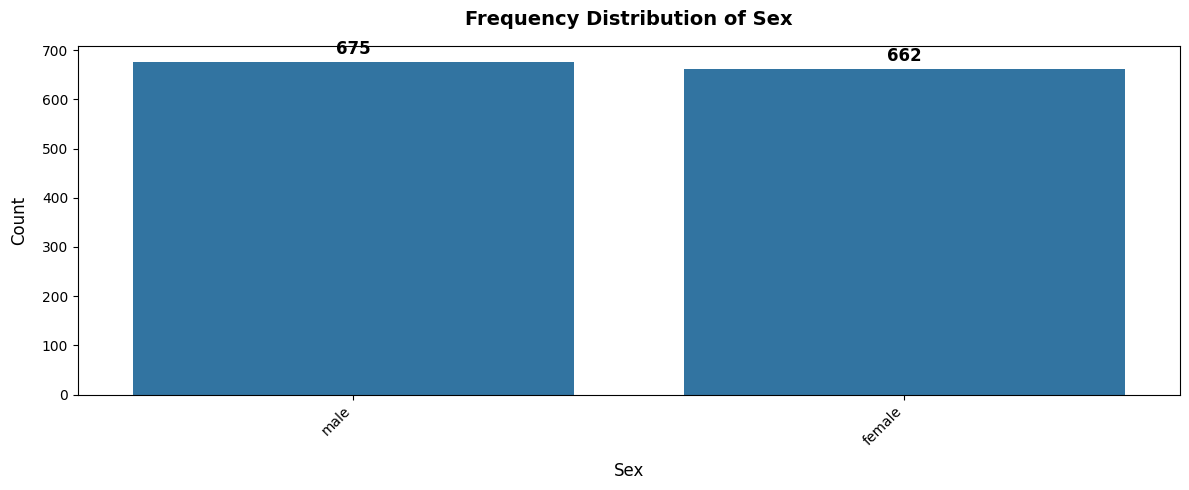

[*] Visualizing feature: Smoker...


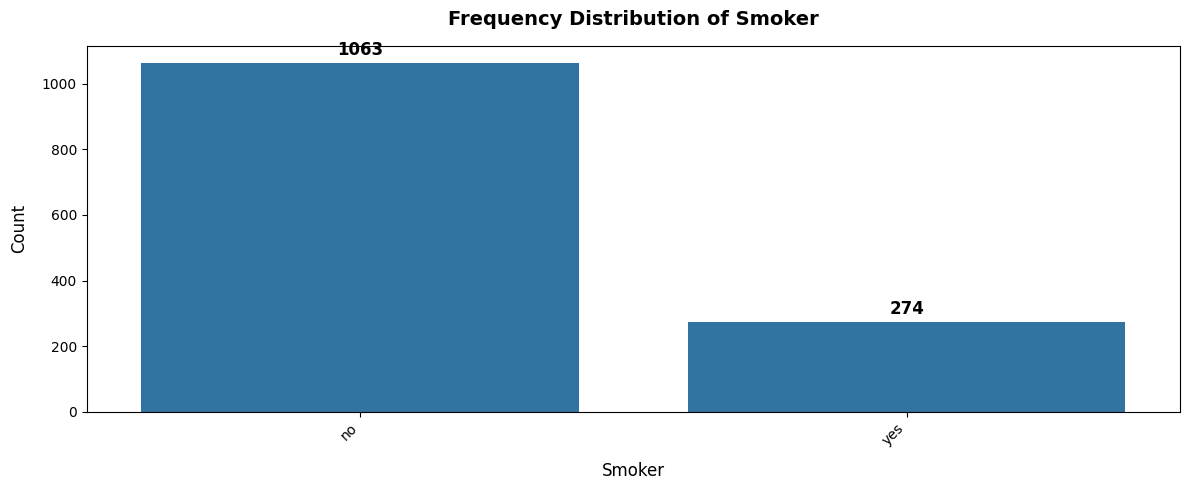

[*] Visualizing feature: Region...


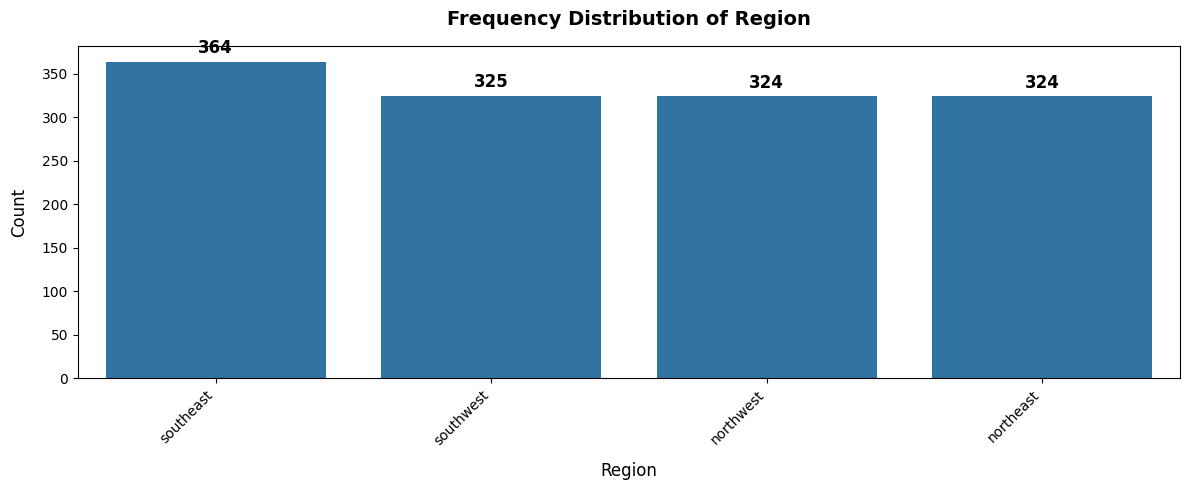

[*] Visualizing feature: Children...


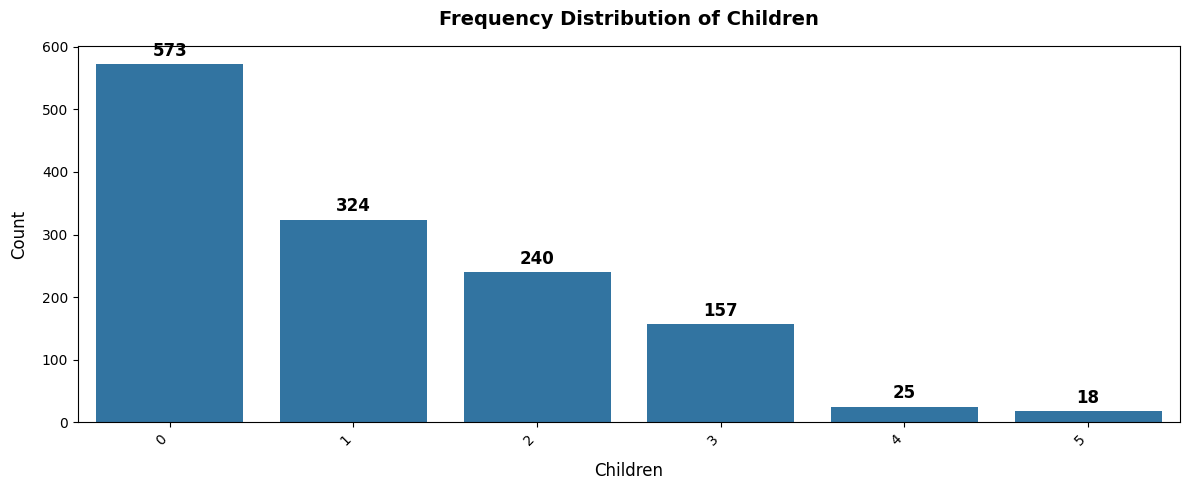

----------------------------------------------------------------------
✅ [SUCCESS] All categorical count plots generated and saved.



In [7]:
# Validation for non-empty categorical column list
if len(cat_columns) > 0:
    # Terminal UI header for count plot rendering
    print("\n" + "="*70)
    print("📊 [ANALYSIS] CATEGORICAL FREQUENCY PLOTS")
    print("="*70)
    
    # Output directory definition
    output_dir = "visualizations/categorical"
    os.makedirs(output_dir, exist_ok=True)
    
    for col in list(cat_columns)  + ["children"]:
        # Formatted feature name for display labels
        col_name = col.replace("_", " ").strip().title()
        print(f"[*] Visualizing feature: {col_name}...")

        # Figure canvas and count plot setup
        plt.figure(figsize=(12, 5))
        ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index)

        # Plot typography and axis definitions
        plt.title(f"Frequency Distribution of {col_name}", fontsize=14, fontweight="bold", pad=15)
        plt.xlabel(col_name, fontsize=12, labelpad=10)
        plt.ylabel("Count", fontsize=12, labelpad=10)

        # Data value annotations on top of the bars
        for container in ax.containers:
            ax.bar_label(container, fmt="%g", padding=3, fontsize=12, fontweight="bold")

        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()

        # Output file generation
        file_path = f"{output_dir}/count_plot_{col}.png"
        plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=False)
        plt.show()

    # Terminal UI footer for successful execution
    print("-" * 70)
    print("✅ [SUCCESS] All categorical count plots generated and saved.\n")

else:
    # Terminal UI fallback for empty categorical lists
    print("\n" + "="*70)
    print("⚠️ [WARNING] Categorical column list is empty. Plotting bypassed.")
    print("="*70 + "\n")


📊 [ANALYSIS] NUMERICAL DISTRIBUTION PLOTS
[*] Visualizing feature: Age...


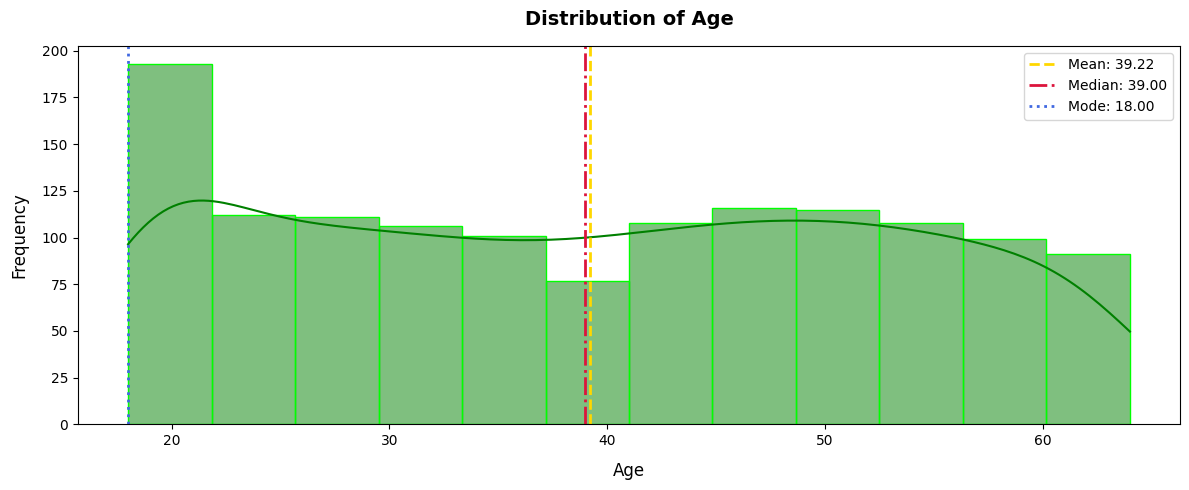

[*] Visualizing feature: Bmi...


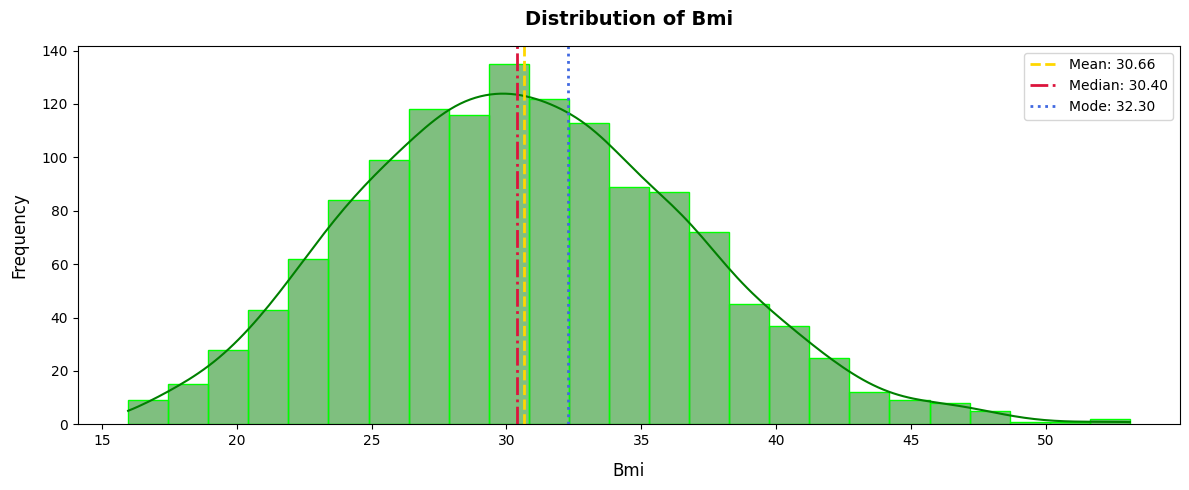

[*] Visualizing feature: Children...


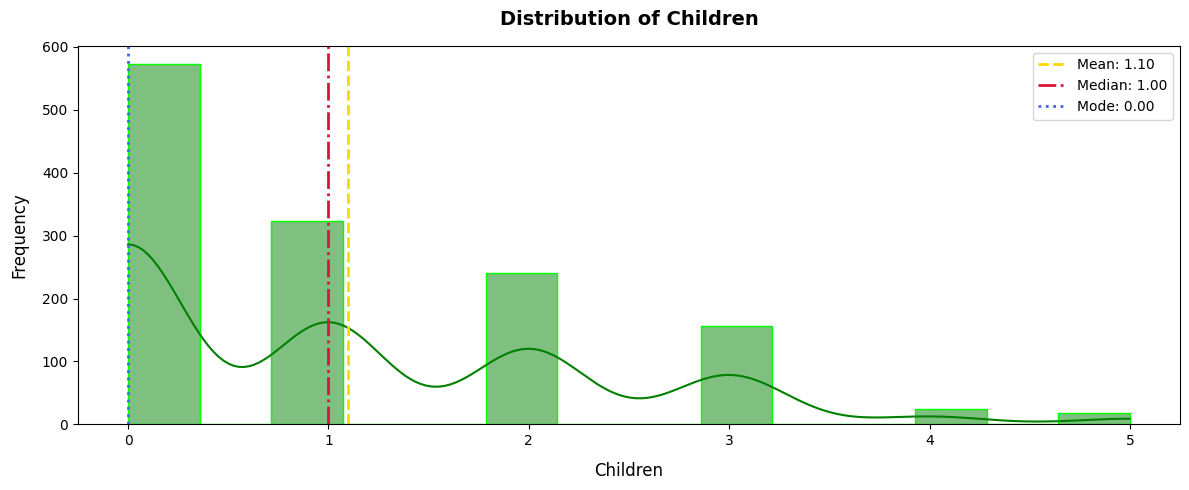

[*] Visualizing feature: Charges...


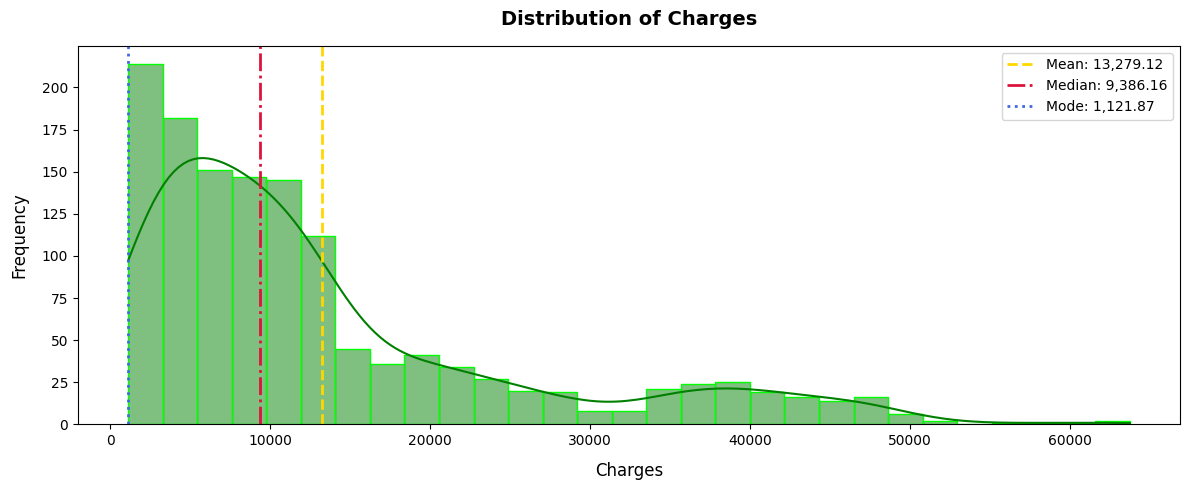

----------------------------------------------------------------------
✅ [SUCCESS] All numerical distribution plots generated and saved.



In [8]:
# Validation for non-empty numerical column list
if len(num_columns) > 0:
    # Terminal UI header for distribution rendering
    print("\n" + "="*70)
    print("📊 [ANALYSIS] NUMERICAL DISTRIBUTION PLOTS")
    print("="*70)
    
    # Output directory definition
    output_dir = "visualizations/numerical"
    os.makedirs(output_dir, exist_ok=True)
    
    for col in num_columns:
        # Formatted feature name for display labels
        col_name = col.replace("_", " ").strip().title()
        print(f"[*] Visualizing feature: {col_name}...")
        
        # Central tendency metrics
        mean_val = df[col].mean()
        median_val = df[col].median()
        mode_val = df[col].mode()[0]
        
        # Figure canvas and histogram plot setup
        plt.figure(figsize=(12, 5))
        sns.histplot(data=df, x=col, kde=True, color="green", edgecolor="lime")
        
        # Vertical statistical markers
        plt.axvline(mean_val, linestyle="--", color="gold", lw=2, label=f"Mean: {mean_val:,.2f}")
        plt.axvline(median_val, linestyle="-.", color="crimson", lw=2, label=f"Median: {median_val:,.2f}")
        plt.axvline(mode_val, linestyle=":", color="royalblue", lw=2, label=f"Mode: {mode_val:,.2f}")
        
        # Plot typography and axis definitions
        plt.title(f"Distribution of {col_name}", fontsize=14, fontweight="bold", pad=15)
        plt.xlabel(col_name, fontsize=12, labelpad=10)
        plt.ylabel("Frequency", fontsize=12, labelpad=10)
        plt.legend(fontsize=10, loc="upper right")
        plt.tight_layout()

        # Output file generation
        file_path = f"{output_dir}/dist_plot_{col}.png"
        plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=False)
        plt.show()
        
    # Terminal UI footer for successful execution
    print("-" * 70)
    print("✅ [SUCCESS] All numerical distribution plots generated and saved.\n")
    
else:
    # Terminal UI fallback for empty numerical lists
    print("\n" + "="*70)
    print("⚠️ [WARNING] Numeric column list is empty. Plotting bypassed.")
    print("="*70 + "\n")


📊 [ANALYSIS] NUMERICAL BOXPLOTS (OUTLIER DETECTION)
[*] Visualizing outliers for feature: Age...


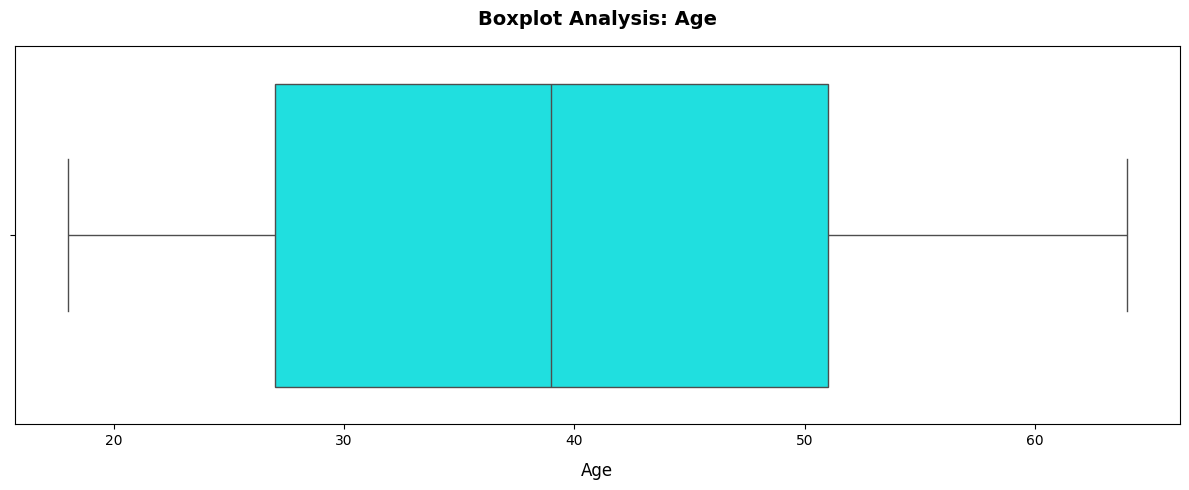

[*] Visualizing outliers for feature: Bmi...


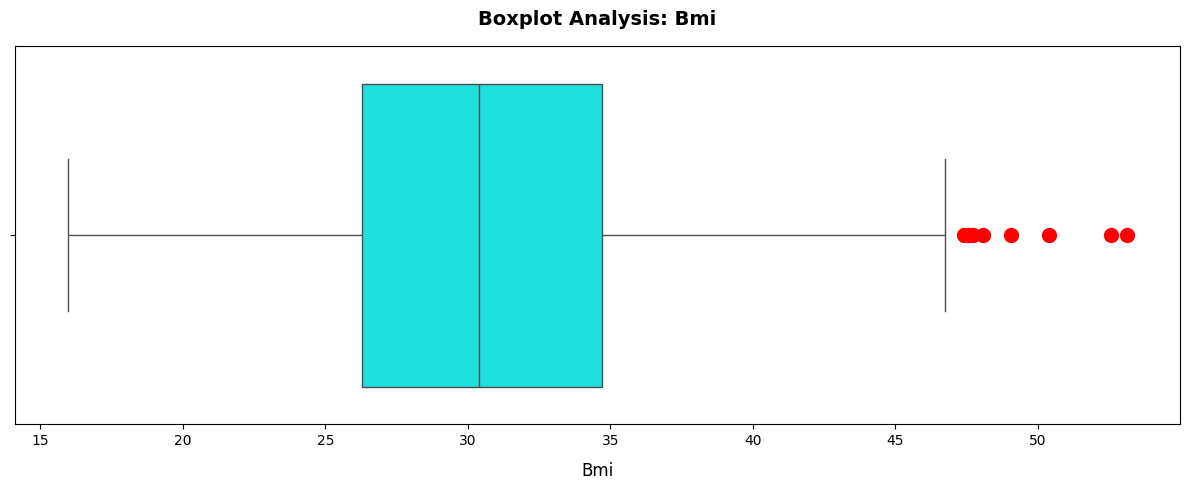

[*] Visualizing outliers for feature: Children...


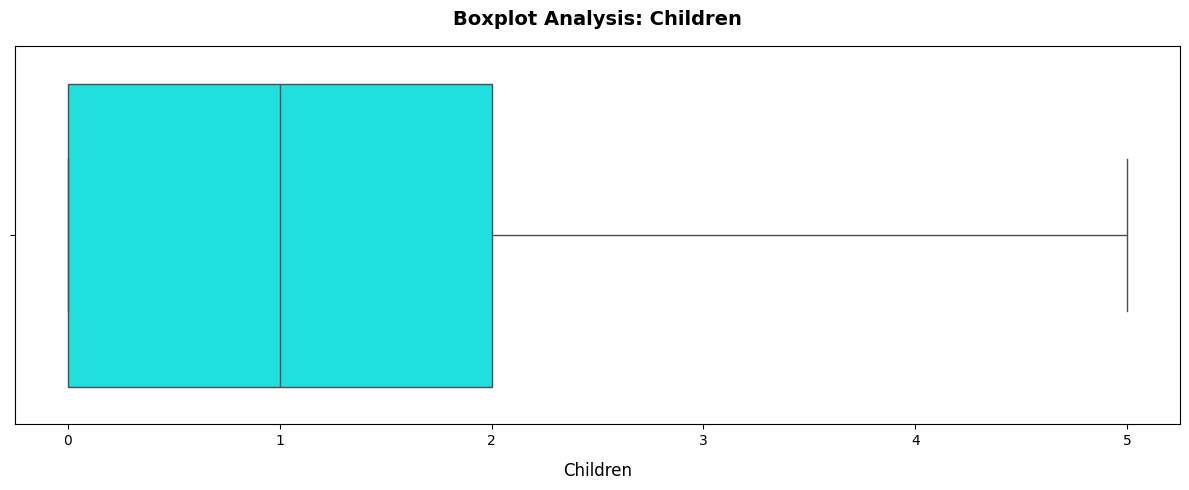

[*] Visualizing outliers for feature: Charges...


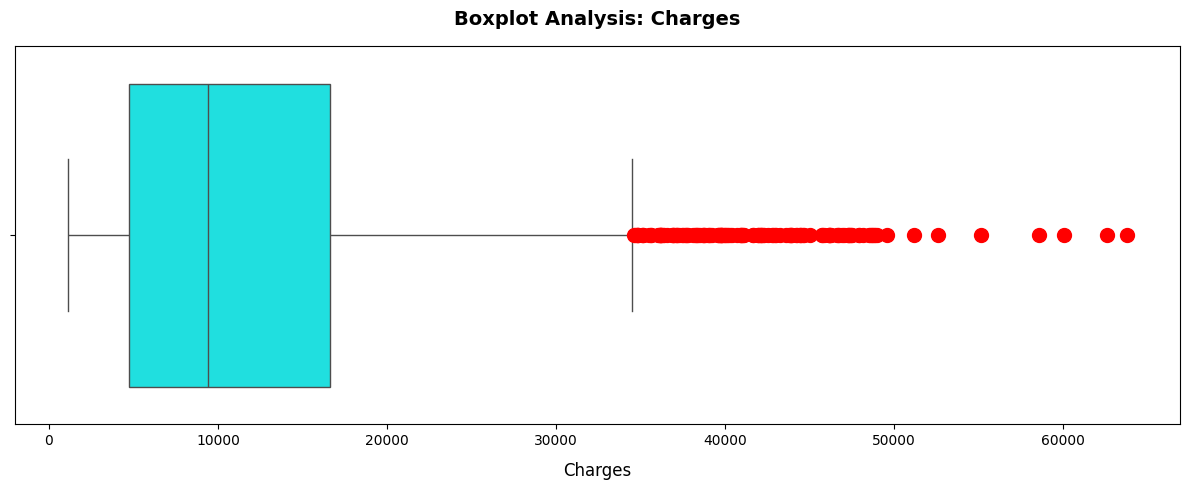

----------------------------------------------------------------------
✅ [SUCCESS] All numerical boxplots generated and saved.



In [9]:
# Validation for non-empty numerical column list
if len(num_columns) > 0:
    # Terminal UI header for boxplot rendering
    print("\n" + "="*70)
    print("📊 [ANALYSIS] NUMERICAL BOXPLOTS (OUTLIER DETECTION)")
    print("="*70)
    
    # Output directory definition
    output_dir = "visualizations/boxplots"
    os.makedirs(output_dir, exist_ok=True)
    
    for col in num_columns:
        # Formatted feature name for display labels
        col_name = col.replace("_", " ").strip().title()
        print(f"[*] Visualizing outliers for feature: {col_name}...")

        # Figure canvas and boxplot setup
        plt.figure(figsize=(12, 5))
        sns.boxplot(
            data=df, 
            x=col, 
            color="cyan", 
            fliersize=10, 
            flierprops={"markerfacecolor": "red", "markeredgecolor": "red"}
        )

        # Plot typography and axis definitions
        plt.title(f"Boxplot Analysis: {col_name}", fontsize=14, fontweight="bold", pad=15)
        plt.xlabel(col_name, fontsize=12, labelpad=10)
        plt.ylabel("")

        plt.tight_layout()

        # Output file generation
        file_path = f"{output_dir}/boxplot_{col}.png"
        plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=False)
        plt.show()

    # Terminal UI footer for successful execution
    print("-" * 70)
    print("✅ [SUCCESS] All numerical boxplots generated and saved.\n")

else:
    # Terminal UI fallback for empty numerical lists
    print("\n" + "="*70)
    print("⚠️ [WARNING] Numeric column list is empty. Boxplot generation bypassed.")
    print("="*70 + "\n")

### 3.3 Relationships with the Target Variable

Before looking at how each feature relates to `charges`, the categorical and
numerical column lists are rebuilt without the target itself. The following
cells then plot `charges` against every other feature: boxplots of charges
grouped by each categorical column, scatter plots of charges against each
numerical column, and a combined boxplot-plus-scatter grid for a side-by-side
outlier view. These are the plots most likely to visually confirm the
non-linear, smoker-driven cost pattern that later shows up numerically in the
model's feature importances.

In [10]:
print("\n" + "="*70)
print("🔠 [FEATURE EXTRACTION] CATEGORICAL COLUMNS")
print("="*70)

# List of categorical column names without the target variable
cat_columns_no_target = [col for col in cat_columns if col != "charges"]
display(cat_columns_no_target)

print("\n" + "="*70)
print("🔢 [FEATURE EXTRACTION] NUMERICAL COLUMNS")
print("="*70)

# List of numeric column names without the target variable
num_columns_no_target = [col for col in num_columns if col != "charges"]
display(num_columns_no_target)
print("="*70 + "\n")


🔠 [FEATURE EXTRACTION] CATEGORICAL COLUMNS


['sex', 'smoker', 'region']


🔢 [FEATURE EXTRACTION] NUMERICAL COLUMNS


['age', 'bmi', 'children']

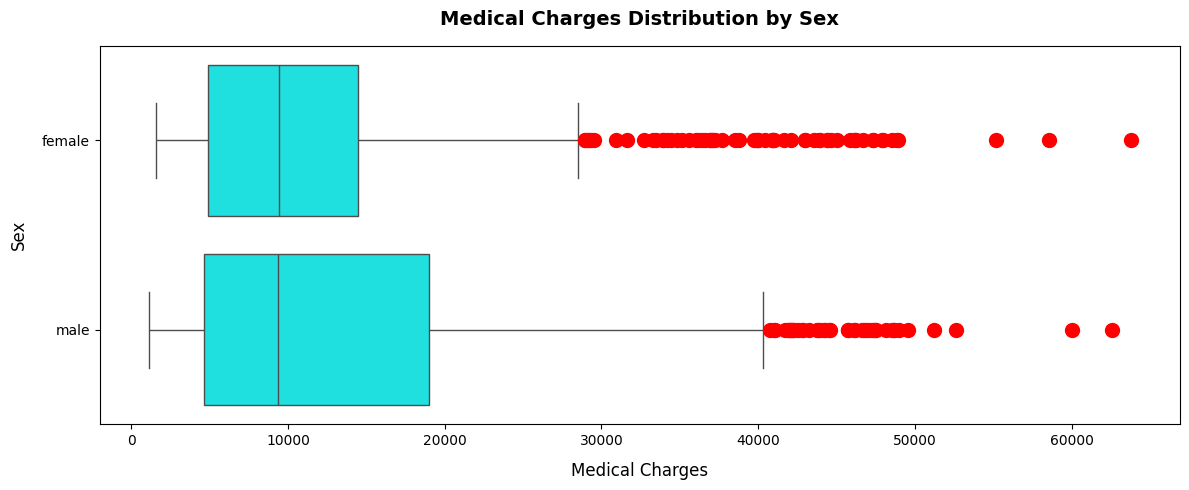

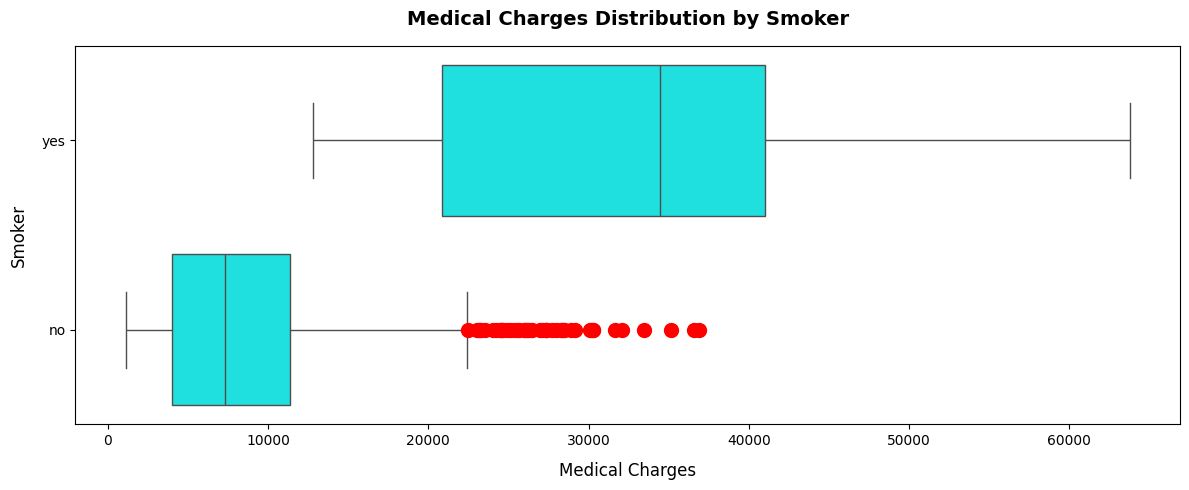

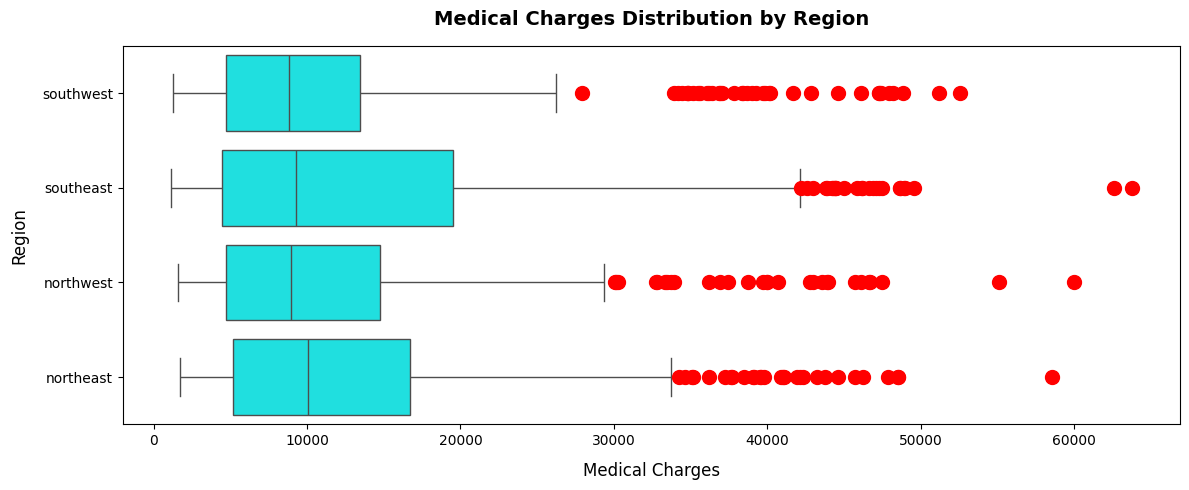

In [11]:
# Conditional branch for the presence of categorical columns
if len(cat_columns_no_target) > 0:
    # Local storage directory for box plot visuals
    output_dir = "visualizations/box_plots"
    os.makedirs(output_dir, exist_ok=True)

    # Iteration block for individual categorical features
    for col in cat_columns_no_target:
        # Formatted string representation for plot typography
        col_name = col.replace("_", " ").strip().title()

        # Two-dimensional spatial canvas for the box plot
        plt.figure(figsize=(12, 5))
        
        # Box plot mapping of the target distribution across categories
        sns.boxplot(
            data=df, 
            x="charges", 
            y=col, 
            color="cyan", 
            fliersize=10, 
            flierprops={"markerfacecolor": "red", "markeredgecolor": "red"}
        )
        
        # Contextual typography and axis labels
        plt.title(f"Medical Charges Distribution by {col_name}", fontsize=14, fontweight="bold", pad=15)
        plt.xlabel("Medical Charges", fontsize=12, labelpad=10)
        plt.ylabel(col_name, fontsize=12, labelpad=10)

        # Figure margin optimization
        plt.tight_layout()

        # Destination file path for the PNG image format
        file_path = f"{output_dir}/boxplot_charges_vs_{col}.png"
        plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=False)
        plt.show()

# Fallback condition for an empty categorical column list
else:
    # Terminal UI output for missing categorical features
    print("\n" + "="*70)
    print("⚠️ [WARNING] No categorical columns available for box plot generation.")
    print("="*70 + "\n")

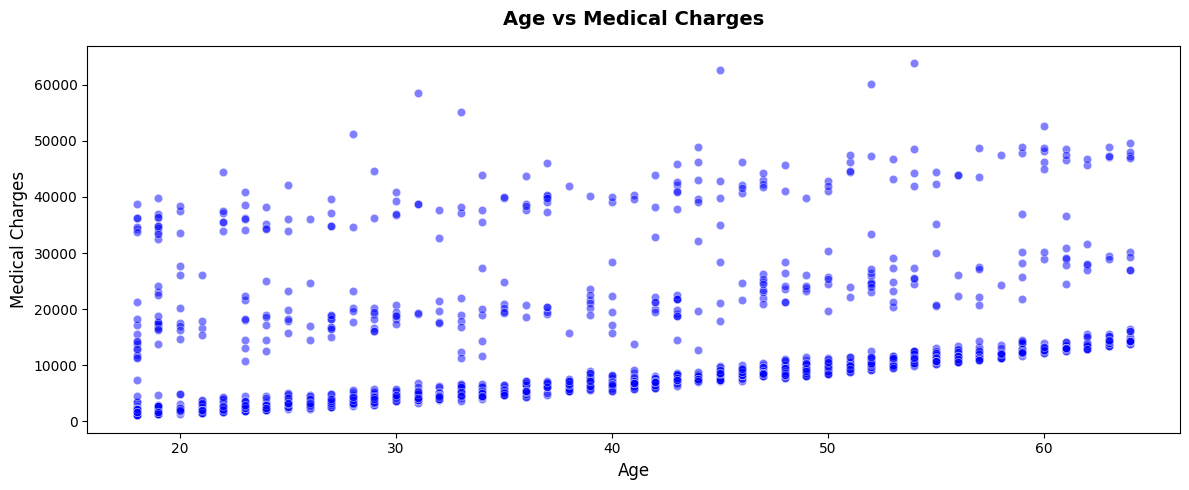

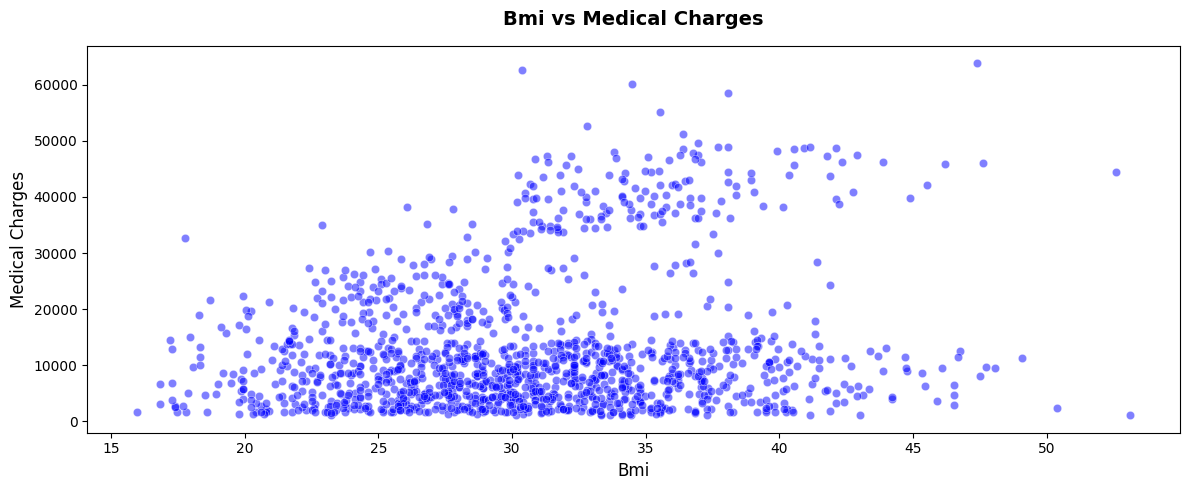

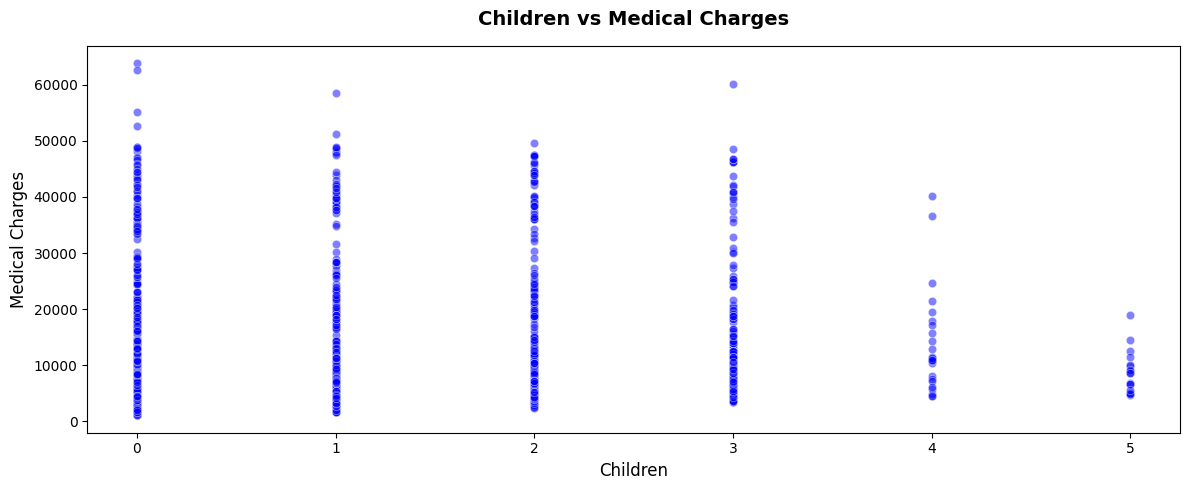

In [12]:
# Conditional branch for the presence of numerical columns
if len(num_columns_no_target) > 0:
    # Local storage directory for scatter plot visuals
    output_dir = "visualizations/scatter_plots"
    os.makedirs(output_dir, exist_ok=True)

    # Iteration block for individual numerical features
    for col in num_columns_no_target:
        # Formatted string representation for plot typography
        col_name = col.replace("_", " ").strip().title()

        # Two-dimensional spatial canvas for the scatter plot
        plt.figure(figsize=(12, 5))
        
        # Scatter plot mapping of the data point distribution against the target variable
        sns.scatterplot(data=df, x=col, y="charges", alpha=0.5, color="blue")
        
        # Contextual typography and axis labels
        plt.title(f"{col_name} vs Medical Charges", fontsize=14, fontweight="bold", pad=15)
        plt.xlabel(col_name, fontsize=12)
        plt.ylabel("Medical Charges", fontsize=12)

        # Figure margin optimization
        plt.tight_layout()

        # Destination file path for the PNG image format
        file_path = f"{output_dir}/scatter_charges_vs_{col}.png"
        plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=False)
        plt.show()

# Fallback condition for an empty numerical column list
else:
    # Terminal UI output for missing numerical features
    print("\n" + "="*70)
    print("⚠️ [WARNING] No numerical columns available for scatter plot generation.")
    print("="*70 + "\n")


📊 [ANALYSIS] NUMERICAL OUTLIER OVERVIEW (GRID)
[*] Rendering overview for feature: Age...
[*] Rendering overview for feature: Bmi...
[*] Rendering overview for feature: Children...
[*] Rendering overview for feature: Charges...


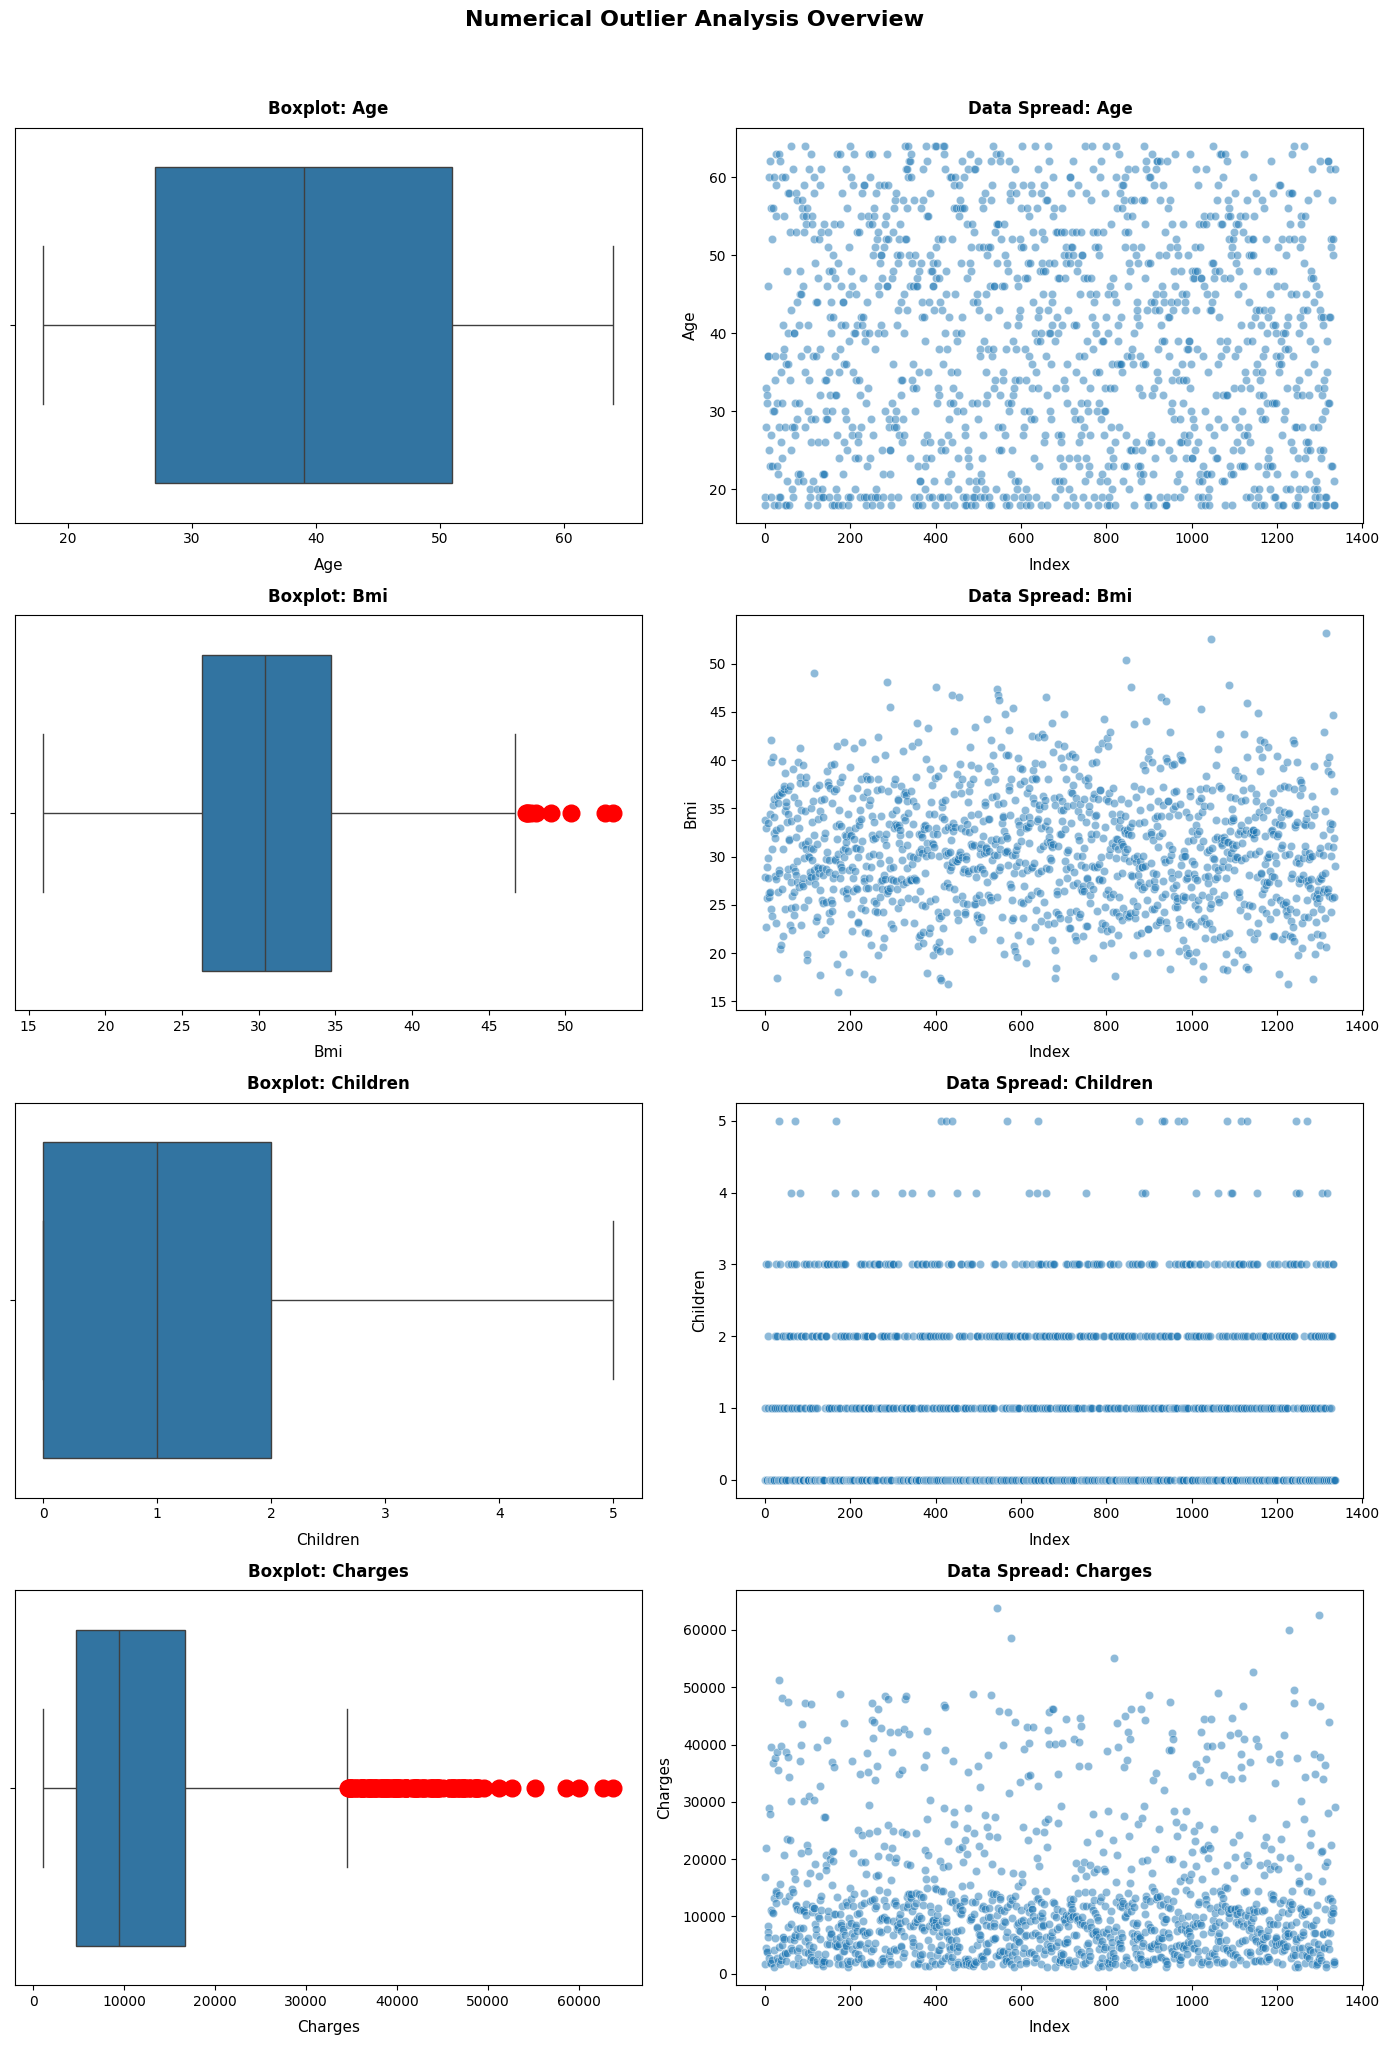

----------------------------------------------------------------------
✅ [SUCCESS] Outlier analysis grid generated and saved.



In [13]:
# Validation for non-empty numerical column list
if len(num_columns) > 0:
    # Terminal UI header for outlier analysis rendering
    print("\n" + "="*70)
    print("📊 [ANALYSIS] NUMERICAL OUTLIER OVERVIEW (GRID)")
    print("="*70)
    
    # Output directory definition
    output_dir = "visualizations"
    os.makedirs(output_dir, exist_ok=True)
    
    n_rows = len(num_columns)
    
    # Figure canvas setup (squeeze=False guarantees a 2D array even if n_rows is 1)
    fig, ax = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows), squeeze=False)

    for i, col in enumerate(num_columns):
        # Formatted feature name for display labels
        col_name = col.replace("_", " ").strip().title()
        print(f"[*] Rendering overview for feature: {col_name}...")

        # Boxplot visualization on the left column (index 0)
        sns.boxplot(
            data=df, 
            x=col, 
            fliersize=12, 
            flierprops={"markerfacecolor": "red", "markeredgecolor": "red"}, 
            ax=ax[i, 0]
        )
        ax[i, 0].set_title(f"Boxplot: {col_name}", fontsize=12, fontweight="bold", pad=10)
        ax[i, 0].set_xlabel(col_name, fontsize=11, labelpad=8)
        ax[i, 0].set_ylabel("")

        # Scatterplot visualization on the right column (index 1)
        sns.scatterplot(
            data=df, 
            x=range(len(df)), 
            y=col, 
            alpha=0.5, 
            ax=ax[i, 1]
        )
        ax[i, 1].set_title(f"Data Spread: {col_name}", fontsize=12, fontweight="bold", pad=10)
        ax[i, 1].set_xlabel("Index", fontsize=11, labelpad=8)
        ax[i, 1].set_ylabel(col_name, fontsize=11, labelpad=8)

    # Master title and layout adjustments
    plt.suptitle("Numerical Outlier Analysis Overview", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()

    # Output file generation
    file_path = f"{output_dir}/outlier_analysis_grid.png"
    plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=False)
    plt.show()

    # Terminal UI footer for successful execution
    print("-" * 70)
    print("✅ [SUCCESS] Outlier analysis grid generated and saved.\n")

else:
    # Terminal UI fallback for empty numerical lists
    print("\n" + "="*70)
    print("⚠️ [WARNING] Numeric column list is empty. Outlier analysis bypassed.")
    print("="*70 + "\n")

### 3.4 Correlation Analysis

`LabelEncoder` is applied to a throwaway copy of the dataframe (`df_eda`)
purely so a numeric Pearson correlation matrix can be computed and plotted
as a heatmap. This encoding is only used for this visualization. It is not
reused anywhere in the actual modeling pipeline below, which builds its own
`ColumnTransformer` instead. The heatmap itself is saved as
`correlation_heatmap.png`, with the exact coefficients annotated directly on
the plot.

In [14]:
# Create a dedicated copy of the dataframe specifically for Exploratory Data Analysis
df_eda = df.copy()

# Validation for non-empty categorical column list
if len(cat_columns) > 0:
    # Terminal UI header for EDA encoding process
    print("\n" + "="*70)
    print("⚙️ [PROCESSING] CATEGORICAL ENCODING FOR EDA")
    print("="*70)
    
    for col in cat_columns:
        # Transform categorical strings into sequential numeric representations
        le = LabelEncoder()
        df_eda[col] = le.fit_transform(df_eda[col])
        print(f"[*] Encoded feature: {col}")
        
    # Terminal UI footer for successful execution
    print("-" * 70)
    print("✅ [SUCCESS] Categorical features encoded in temporary EDA dataset.\n")

else:
    # Terminal UI fallback for empty categorical lists
    print("\n" + "="*70)
    print("⚠️ [WARNING] Categorical column list is empty. Encoding bypassed.")
    print("="*70 + "\n")


⚙️ [PROCESSING] CATEGORICAL ENCODING FOR EDA
[*] Encoded feature: sex
[*] Encoded feature: smoker
[*] Encoded feature: region
----------------------------------------------------------------------
✅ [SUCCESS] Categorical features encoded in temporary EDA dataset.




📊 [ANALYSIS] CORRELATION MATRIX HEATMAP
[*] Computing Pearson correlation coefficients...


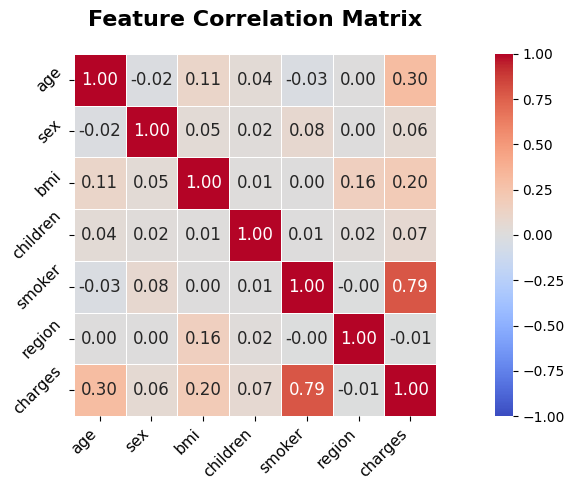

----------------------------------------------------------------------
✅ [SUCCESS] Correlation matrix heatmap generated and saved.



In [15]:
# Terminal UI header for the correlation matrix analysis
print("\n" + "="*70)
print("📊 [ANALYSIS] CORRELATION MATRIX HEATMAP")
print("="*70)

# Output directory path definition and creation
output_dirs = "visualizations"
os.makedirs(output_dirs, exist_ok=True)

print("[*] Computing Pearson correlation coefficients...")

# Pearson correlation matrix calculation for the encoded dataset
df_corr = df_eda.corr()

# Figure canvas initialization
plt.figure(figsize=(12, 5))

# Heatmap visualization of the correlation matrix
sns.heatmap(
    df_corr, annot=True, fmt=".2f", cmap="coolwarm",
    linewidth=0.5, square=True, vmin=-1, vmax=1, annot_kws={"size": 12}
)

# Typography and axis label configuration
plt.title("Feature Correlation Matrix", fontsize=16, fontweight="bold", pad=20)
plt.xticks(fontsize=11, rotation=45, ha="right")
plt.yticks(fontsize=11, rotation=45)

plt.tight_layout()

# Output file generation and export
file_path = "correlation_heatmap.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=False)
plt.show()

# Terminal UI footer for successful execution log
print("-" * 70)
print("✅ [SUCCESS] Correlation matrix heatmap generated and saved.\n")

### 3.5 Re-Verifying Data Integrity Before Modeling

This cell reruns the exact same profiling routine used earlier in Section 3.
It is a deliberate sanity check to reconfirm that `df` is still clean
(no missing values, no duplicates) right before it gets split into features
and target, since a fair amount of intermediate exploration happened in
between.

In [16]:
# ==============================================================================
# 0. DATASET PREVIEW
# ==============================================================================
print("=" * 60)
print(" DATASET PREVIEW ".center(60, "="))
print("=" * 60)
print("-> HEAD (Top 5 Rows):")
display(df.head())

print("\n-> TAIL (Bottom 5 Rows):")
display(df.tail())

print("\n-> SAMPLE (Random 5 Rows):")
display(df.sample(5))

print("-" * 60)
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
print("=" * 60 + "\n")


# ==============================================================================
# 1. DATASET BASIC INFORMATION
# ==============================================================================
print("=" * 60)
print(" DATASET INFORMATION ".center(60, "="))
print("=" * 60)
display(df.info())
print("\n")


# ==============================================================================
# 2. STATISTICAL DESCRIPTION
# ==============================================================================
print("=" * 60)
print(" STATISTICAL DESCRIPTION ".center(60, "="))
print("=" * 60)
display(df.describe(include="all"))
print("\n")


# ==============================================================================
# 3. MISSING VALUES CHECK
# ==============================================================================
print("=" * 60)
print(" MISSING VALUES ".center(60, "="))
print("=" * 60)

null_counts = df.isnull().sum()
display(null_counts)

if null_counts.sum() > 0:
    display(df[df.isnull().any(axis=1)])
else:
    print("No missing values found.")
print("\n")


# ==============================================================================
# 4. DUPLICATED ROWS CHECK
# ==============================================================================
print("=" * 60)
print(" DUPLICATED ROWS ".center(60, "="))
print("=" * 60)

duplicated_num = df.duplicated().sum()
print(f"Total duplicated rows found: {duplicated_num}")

if duplicated_num > 0:
    display(df[df.duplicated()])
else:
    print("No duplicated rows found.")
print("\n")


# ==============================================================================
# 5. UNIQUE VALUES PER COLUMN
# ==============================================================================
print("=" * 60)
print(" UNIQUE VALUES PER COLUMN ".center(60, "="))
print("=" * 60)

for column in df.columns:
    unique_count = df[column].nunique()
    col_type = df[column].dtype

    print(f"🔹 Column: '{column}' | Type: {col_type} | Unique Values: {unique_count}")

    # Display unique values safely based on count
    if unique_count <= 20:
        print(f"   Values : {df[column].unique()}")
    else:
        print(f"   Values : {df[column].unique()[:5]} ... [Showing first 5]")

    # Detail distributions specifically for Categorical data
    if col_type == "object":
        print("\n   --- Value Counts ---")
        print(f"   {df[column].value_counts().to_string().replace(chr(10), chr(10) + '   ')}")
    else:
        print("\n   --- Numeric Column ---")

    print("=" * 60)

===================== DATASET PREVIEW ======================
-> HEAD (Top 5 Rows):


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



-> TAIL (Bottom 5 Rows):


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



-> SAMPLE (Random 5 Rows):


...



================= STATISTICAL DESCRIPTION ==================


,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450




====================== MISSING VALUES ======================


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No missing values found.


===================== DUPLICATED ROWS ======================
Total duplicated rows found: 0
No duplicated rows found.


================= UNIQUE VALUES PER COLUMN =================
🔹 Column: 'age' | Type: int64 | Unique Values: 47
   Values : [19 18 28 33 32] ... [Showing first 5]

   --- Numeric Column ---
🔹 Column: 'sex' | Type: object | Unique Values: 2
   Values : ['female' 'male']

   --- Value Counts ---
   sex
   male      675
   female    662
🔹 Column: 'bmi' | Type: float64 | Unique Values: 548
   Values : [27.9   33.77  33.    22.705 28.88 ] ... [Showing first 5]

   --- Numeric Column ---
🔹 Column: 'children' | Type: int64 | Unique Values: 6
   Values : [0 1 3 2 5 4]

   --- Numeric Column ---
🔹 Column: 'smoker' | Type: object | Unique Values: 2
   Values : ['yes' 'no']

   --- Value Counts ---
   smoker
   no     1063
   yes     274
🔹 Column: 'region' | Type: object | Unique Values: 4
   Values : ['southwest' 'southeast' 'northwest' 'northeast']

 

## 4. Preparing Data for Modeling

`X` is created by dropping the `charges` column, and `y` is set to `charges`
alone. `X` is then split into training and test sets with an 80/20 ratio
(`random_state=42`), giving 1,069 training rows and 268 held-out test rows,
as confirmed by the printed shapes below. The test set is not touched again
until the final evaluation in Section 10.

In [17]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

print("=" * 40)
print("📊 DATASET SPLIT SUMMARY".center(40))
print("=" * 40)
print(f"▶ X_train shape : {X_train.shape}")
print(f"▶ X_test shape  : {X_test.shape}")
print(f"▶ y_train shape : {y_train.shape}")
print(f"▶ y_test shape  : {y_test.shape}")
print("=" * 40)

        📊 DATASET SPLIT SUMMARY         
▶ X_train shape : (1069, 6)
▶ X_test shape  : (268, 6)
▶ y_train shape : (1069,)
▶ y_test shape  : (268,)


## 5. Candidate Models and Preprocessing Pipeline

Nine regression models are defined in a dictionary so they can all be looped
over identically in the next section: `Linear`, `Ridge`, and `Lasso`
Regression, a `Decision Tree`, `Random Forest`, `XGBoost`, `LightGBM`, `KNN`,
and a `Yeo-Johnson Linear` variant that wraps `LinearRegression` in a
`TransformedTargetRegressor` so the model is fit on a power-transformed
target and automatically inverse-transformed at prediction time.

A single shared preprocessing step is then defined as a `ColumnTransformer`.
It applies a standardized Yeo-Johnson `PowerTransformer` to the numeric
columns (`age`, `bmi`, `children`), an `OrdinalEncoder` to the two binary
categorical columns (`sex`, `smoker`), and a `OneHotEncoder` to `region`.
`remainder="passthrough"` is set as a safeguard, although in practice every
column in `X` is already covered by one of the three explicit transformers.
This same `transformers` object is reused in every pipeline built for the
rest of the notebook, so every model sees identically preprocessed data.

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=random_state),
    "Random Forest": RandomForestRegressor(random_state=random_state),
    "XGBoost": XGBRegressor(random_state=random_state),
    "LightGBM": LGBMRegressor(random_state=random_state, verbose=-1),
    "KNN Regressor": KNeighborsRegressor(),
    "Yeo-Johnson Linear": TransformedTargetRegressor(
        regressor=LinearRegression(),
        transformer=PowerTransformer(method="yeo-johnson", standardize=False)
    )
}

In [20]:
transformers = ColumnTransformer(
    transformers = [
        (
            "Yeo-Johnson",
            PowerTransformer(method="yeo-johnson", standardize=True),
            num_columns_no_target
        ),
        (
            "Binary Encoder",
            OrdinalEncoder(),
            binary_cat_columns            
        ),
        (
            "OHE",
            OneHotEncoder(sparse_output=False),
            multi_cat_columns
        )
    ],
    remainder="passthrough"
).set_output(transform="pandas")

## 6. Baseline Cross-Validation Benchmark

Each of the nine candidate models is wrapped in a `Pipeline` with the shared
preprocessing step, then evaluated with 5-fold `KFold` cross-validation
(`scoring="r2"`) on the training set only. The mean and per-fold scores are
collected, reshaped into a long-format table for plotting, and visualized as
two bar charts. This is the first point in the notebook where the models are
compared directly against each other on equal footing.

In [21]:
kf = KFold(n_splits=5, random_state=random_state, shuffle=True)

all_model_scores = {}
all_model_scores_mean = {}

for model_name, model in models.items():
    start_time = time.time()

    pipeline = Pipeline(
        steps=[
            ("Preprocessing", transformers), 
            ("Model", model)
        ]
    )

    scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring="r2")
    scores_mean = np.mean(scores)
    scores_std = np.std(scores)

    end_time = time.time()
    total_seconds = end_time - start_time
    minutes = int(total_seconds // 60)
    seconds = total_seconds % 60
    elapsed_time = f"{minutes}m {seconds:.2f}s"

    print(f"[*] Model: {model_name:<20} | Time: {elapsed_time:<10} | R2 Mean: {scores_mean:.4f} | R2 Std: {scores_std:.4f}")

    all_model_scores[model_name] = scores
    all_model_scores_mean[model_name] = [scores_mean]

[*] Model: Linear Regression    | Time: 0m 0.17s   | R2 Mean: 0.7207 | R2 Std: 0.0290
[*] Model: Ridge Regression     | Time: 0m 0.16s   | R2 Mean: 0.7207 | R2 Std: 0.0285
[*] Model: Lasso Regression     | Time: 0m 0.15s   | R2 Mean: 0.7207 | R2 Std: 0.0289
[*] Model: Decision Tree        | Time: 0m 0.17s   | R2 Mean: 0.6613 | R2 Std: 0.0629
[*] Model: Random Forest        | Time: 0m 2.19s   | R2 Mean: 0.8208 | R2 Std: 0.0345
[*] Model: XGBoost              | Time: 0m 0.62s   | R2 Mean: 0.7849 | R2 Std: 0.0327
[*] Model: LightGBM             | Time: 0m 0.55s   | R2 Mean: 0.8169 | R2 Std: 0.0317
[*] Model: KNN Regressor        | Time: 0m 0.17s   | R2 Mean: 0.5871 | R2 Std: 0.0404
[*] Model: Yeo-Johnson Linear   | Time: 0m 0.18s   | R2 Mean: 0.5554 | R2 Std: 0.0976


In [22]:
cross_val_df = pd.DataFrame(
    all_model_scores,
    index=[f"Fold {i+1}" for i in range(5)]
)
cross_val_df.loc["Mean"] = {model_name: model_scores[0] for model_name, model_scores in all_model_scores_mean.items()}
display(cross_val_df)

,Linear Regression,Ridge Regression,Lasso Regression,Decision Tree,Random Forest,XGBoost,LightGBM,KNN Regressor,Yeo-Johnson Linear
Fold 1,0.724867,0.724846,0.724852,0.607757,0.783533,0.748840,0.790726,0.579189,0.550213
Fold 2,0.715303,0.715287,0.715355,0.622271,0.821162,0.769796,0.809916,0.555368,0.503559
Fold 3,0.772174,0.771345,0.772159,0.740659,0.876252,0.835210,0.874086,0.629389,0.698813
Fold 4,0.684732,0.685434,0.684836,0.600902,0.785707,0.760209,0.785809,0.534301,0.410702
Fold 5,0.706202,0.706500,0.706239,0.735102,0.837201,0.810611,0.824110,0.637112,0.613835
Mean,0.720656,0.720682,0.720688,0.661338,0.820771,0.784933,0.816929,0.587072,0.555424


In [23]:
cross_val_plot_df = cross_val_df.reset_index().rename(columns={"index": "Fold"})
cross_val_plot_df = pd.melt(cross_val_plot_df, id_vars="Fold", var_name="Model", value_name="Scores")
display(cross_val_plot_df.head(12))

,Fold,Model,Scores
0,Fold 1,Linear Regression,0.724867
1,Fold 2,Linear Regression,0.715303
2,Fold 3,Linear Regression,0.772174
3,Fold 4,Linear Regression,0.684732
4,Fold 5,Linear Regression,0.706202
5,Mean,Linear Regression,0.720656
6,Fold 1,Ridge Regression,0.724846
7,Fold 2,Ridge Regression,0.715287
8,Fold 3,Ridge Regression,0.771345
9,Fold 4,Ridge Regression,0.685434



📊 [ANALYSIS] CROSS-VALIDATION SCORES EVALUATION
[*] Rendering cross-validation comparison plots...


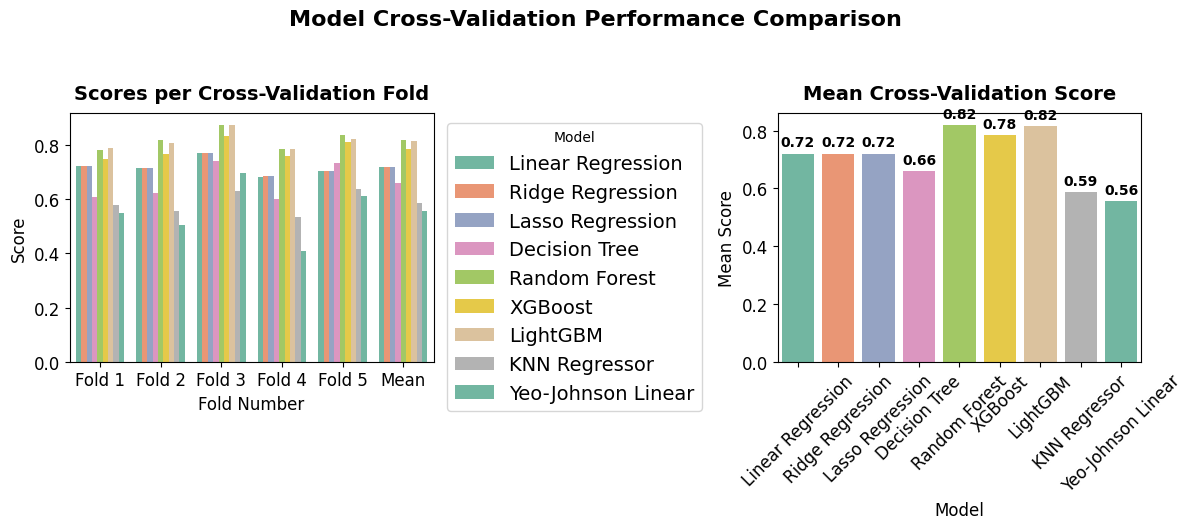

----------------------------------------------------------------------
✅ [SUCCESS] Cross-validation plots generated and saved.



In [24]:
# Terminal UI header for cross-validation rendering
print("\n" + "="*70)
print("📊 [ANALYSIS] CROSS-VALIDATION SCORES EVALUATION")
print("="*70)

# Output directory path definition and creation
output_dir = "visualizations"
os.makedirs(output_dir, exist_ok=True)

print("[*] Rendering cross-validation comparison plots...")

# Figure canvas and subplots initialization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Barplot visualization for individual fold scores across models
sns.barplot(data=cross_val_plot_df, x="Fold", y="Scores", hue="Model", palette="Set2", ax=ax[0])
ax[0].set_title("Scores per Cross-Validation Fold", fontsize=14, fontweight="bold", pad=10)
ax[0].set_xlabel("Fold Number", fontsize=12)
ax[0].set_ylabel("Score", fontsize=12)
ax[0].tick_params(axis="both", labelsize=12)
ax[0].legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=14)

# Barplot visualization for mean validation scores across models
sns.barplot(x=cross_val_df.columns, y=cross_val_df.loc["Mean"], palette="Set2", ax=ax[1])
ax[1].set_title("Mean Cross-Validation Score", fontsize=14, fontweight="bold", pad=10)
ax[1].set_xlabel("Model", fontsize=12)
ax[1].set_ylabel("Mean Score", fontsize=12)
ax[1].tick_params(axis="x", rotation=45, labelsize=12)
ax[1].tick_params(axis="y", labelsize=12)

# Data value annotations on top of the bars
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.2f", padding=3, fontsize=10, fontweight="bold")

# Master title and layout adjustments
plt.suptitle("Model Cross-Validation Performance Comparison", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()

# Output file generation and export
file_path = "cross_val_comparison.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=False)
plt.show()

# Terminal UI footer for successful execution log
print("-" * 70)
print("✅ [SUCCESS] Cross-validation plots generated and saved.\n")

### 6.1 Ranking the Models and Selecting Candidates for Tuning

Sorting the mean cross-validation scores puts **Random Forest** at the top,
with **LightGBM** close behind. Both clear the rest of the field by a wide
margin, XGBoost lands a step below them, the three linear-family models
cluster together further down, and Decision Tree, KNN, and the Yeo-Johnson
Linear variant trail furthest behind (the exact scores are printed in the
output above).

The original plan was to simply carry the single best model, Random Forest,
into tuning. However, Random Forest and LightGBM finished close enough to
each other that picking a winner from the baseline table alone would have
been premature. It is entirely possible for a hyperparameter search to
unlock more headroom in one model than the other, so **both** Random Forest
and LightGBM are carried forward into the tuning stage in Section 7,
specifically to check whether tuning closes that gap or flips the ranking
altogether.

In [25]:
# Terminal UI header for model evaluation summary
print("\n" + "="*70)
print("🏆 [ANALYSIS] CROSS-VALIDATION SUMMARY & BEST MODEL")
print("="*70)

# Convert the dictionary of mean scores into a structured dataframe
cv_summary_df = pd.DataFrame(all_model_scores_mean).T.reset_index()
cv_summary_df.columns = ["Model", "Mean_R2_Score"]

# Sort the dataframe by score in descending order and reset the index to ensure sequential ordering
cv_summary_df = cv_summary_df.sort_values(by="Mean_R2_Score", ascending=False).reset_index(drop=True)

# Render the sorted summary table in the environment
display(cv_summary_df)

# Extract the top-performing model's name and its corresponding metric using the newly ordered index
best_cv_model_name = cv_summary_df.loc[0, "Model"]
best_cv_r2_score = cv_summary_df.loc[0, "Mean_R2_Score"]

# Terminal UI tabular output for the optimal model selection
print("\n" + "=" * 70)
print("             CV-BASED MODEL SELECTION")
print("=" * 70)
print(f"Best Model    : {best_cv_model_name}")
print(f"Mean R2 Score : {best_cv_r2_score:.4f}")
print("=" * 70 + "\n")


🏆 [ANALYSIS] CROSS-VALIDATION SUMMARY & BEST MODEL


,Model,Mean_R2_Score
0,Random Forest,0.820771
1,LightGBM,0.816929
2,XGBoost,0.784933
3,Lasso Regression,0.720688
4,Ridge Regression,0.720682
5,Linear Regression,0.720656
6,Decision Tree,0.661338
7,KNN Regressor,0.587072
8,Yeo-Johnson Linear,0.555424



             CV-BASED MODEL SELECTION
Best Model    : Random Forest
Mean R2 Score : 0.8208



## 7. Hyperparameter Tuning

Both Random Forest and LightGBM are now tuned three separate ways each,
`GridSearchCV`, `RandomizedSearchCV`, and `Optuna`, for a total of six tuning
runs. Running all three strategies on both models is what lets Section 7.7
below compare not just the two models, but also which tuning strategy found
the better configuration for each of them.

### 7.1 Random Forest, GridSearchCV

`GridSearchCV` exhaustively evaluates every combination in a fixed grid of 5
hyperparameters (324 combinations in total), each scored with 5-fold
cross-validation, for 1,620 model fits overall. This is the most thorough
but also the slowest of the three strategies used here.

In [26]:
# Terminal UI header for Random Forest Hyperparameter Tuning
print("\n" + "="*70)
print("⚙️ [OPTIMIZATION] RANDOM FOREST GRID SEARCH CV")
print("="*70)

# Execution timer initialization
start_time = time.time()

# Pipeline construction integrating preprocessing and the Random Forest estimator
selected_rf_pipeline = Pipeline(
    steps=[
        ("Preprocessing", transformers),
        ("Model", RandomForestRegressor(random_state=random_state))
    ]
)

# Hyperparameter grid specification for Random Forest Regressor
rf_param_grid = {
    "Model__n_estimators": [100, 200, 300],          # Number of trees in the forest
    "Model__max_depth": [None, 10, 20, 30],          # Maximum depth of the tree
    "Model__min_samples_split": [2, 5, 10],          # Minimum number of samples required to split an internal node
    "Model__min_samples_leaf": [1, 2, 4],            # Minimum number of samples required to be at a leaf node
    "Model__max_features": ["sqrt", "log2", 1.0]     # Number of features to consider when looking for the best split
}

# Cross-validation strategy configuration
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

print("[*] Initializing and executing GridSearchCV. This may take a while...")

# Grid search engine initialization
grid_search_rf = GridSearchCV(
    estimator=selected_rf_pipeline,
    param_grid=rf_param_grid,
    cv=kf,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    error_score=np.nan
)

# Execution of the hyperparameter search over the training data
grid_search_rf.fit(X_train, y_train)

# Execution time calculation
end_time = time.time()
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = total_seconds % 60
elapsed_time = f"{minutes}m {seconds:.2f}s"

# Terminal UI output for tuning results
print("\n" + "-" * 70)
print(f"⏱️ [EXECUTION TIME] {elapsed_time}")
print(f"🏆 [BEST SCORE] Mean R2 Score : {grid_search_rf.best_score_:.4f}")
print("-" * 70)
print("📌 [BEST HYPERPARAMETERS]:")

# Iteration and extraction of the optimal parameters without the pipeline prefix
for param, value in grid_search_rf.best_params_.items():
    clean_param_name = param.replace('Model__', '')
    print(f"   - {clean_param_name:<20}: {value}")

print("="*70 + "\n")


⚙️ [OPTIMIZATION] RANDOM FOREST GRID SEARCH CV
[*] Initializing and executing GridSearchCV. This may take a while...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

----------------------------------------------------------------------
⏱️ [EXECUTION TIME] 5m 45.71s
🏆 [BEST SCORE] Mean R2 Score : 0.8395
----------------------------------------------------------------------
📌 [BEST HYPERPARAMETERS]:
   - max_depth           : 10
   - max_features        : 1.0
   - min_samples_leaf    : 4
   - min_samples_split   : 10
   - n_estimators        : 300



### 7.2 Random Forest, RandomizedSearchCV

`RandomizedSearchCV` searches an expanded hyperparameter space (now including
`bootstrap`) but only samples 50 random combinations instead of testing every
one, for 250 fits total. This trades exhaustiveness for speed.

In [27]:
# Terminal UI header for Random Forest Hyperparameter Tuning
print("\n" + "="*70)
print("⚙️ [OPTIMIZATION] RANDOM FOREST RANDOMIZED SEARCH CV")
print("="*70)

# Execution timer initialization
start_time = time.time()

# Pipeline construction integrating preprocessing and the Random Forest estimator
selected_rf_pipeline = Pipeline(
    steps=[
        ("Preprocessing", transformers),
        ("Model", RandomForestRegressor(random_state=random_state))
    ]
)

# Expanded hyperparameter distribution specification for Random Forest Regressor
rf_param_dist = {
    "Model__n_estimators": [100, 200, 300, 500, 800, 1000],  # Expanded number of trees
    "Model__max_depth": [None, 10, 20, 30, 40, 50],          # Expanded maximum depth of the tree
    "Model__min_samples_split": [2, 5, 10, 15, 20],          # Expanded minimum samples required to split an internal node
    "Model__min_samples_leaf": [1, 2, 4, 8, 10],             # Expanded minimum samples required to be at a leaf node
    "Model__max_features": ["sqrt", "log2", 1.0],            # Number of features to consider when looking for the best split
    "Model__bootstrap": [True, False]                        # Method for sampling data points (with or without replacement)
}

# Cross-validation strategy configuration
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

print("[*] Initializing and executing RandomizedSearchCV. This may take a while...")

# Randomized search engine initialization
random_search_rf = RandomizedSearchCV(
    estimator=selected_rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=kf,
    scoring="r2",
    random_state=random_state,
    n_jobs=-1,
    verbose=1,
    error_score=np.nan
)

# Execution of the hyperparameter search over the training data
random_search_rf.fit(X_train, y_train)

# Execution time calculation
end_time = time.time()
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = total_seconds % 60
elapsed_time = f"{minutes}m {seconds:.2f}s"

# Terminal UI output for tuning results
print("\n" + "-" * 70)
print(f"⏱️ [EXECUTION TIME] {elapsed_time}")
print(f"🏆 [BEST SCORE] Mean R2 Score : {random_search_rf.best_score_:.4f}")
print("-" * 70)
print("📌 [BEST HYPERPARAMETERS]:")

# Iteration and extraction of the optimal parameters without the pipeline prefix
for param, value in random_search_rf.best_params_.items():
    clean_param_name = param.replace('Model__', '')
    print(f"   - {clean_param_name:<20}: {value}")

print("="*70 + "\n")


⚙️ [OPTIMIZATION] RANDOM FOREST RANDOMIZED SEARCH CV
[*] Initializing and executing RandomizedSearchCV. This may take a while...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

----------------------------------------------------------------------
⏱️ [EXECUTION TIME] 1m 52.65s
🏆 [BEST SCORE] Mean R2 Score : 0.8425
----------------------------------------------------------------------
📌 [BEST HYPERPARAMETERS]:
   - n_estimators        : 300
   - min_samples_split   : 15
   - min_samples_leaf    : 8
   - max_features        : 1.0
   - max_depth           : 10
   - bootstrap           : True



### 7.3 Random Forest, Optuna

Optuna runs a guided, trial-by-trial search. Each trial samples a set of
hyperparameters, builds a pipeline with them, scores it with the same 5-fold
cross-validation used everywhere else in this notebook, and Optuna uses that
result to inform where to sample next. 50 trials are run here, matching the
trial budget used for `RandomizedSearchCV` above so the two strategies are
compared on equal footing. The study's sampler (`TPESampler`) is seeded with
the same `random_state` used throughout this notebook, so which
hyperparameters get sampled at each trial, and therefore the final result,
is reproducible across reruns rather than shifting each time like an
unseeded Optuna study normally would.

In [28]:
# Execution timer initialization
start_time = time.time()

# Terminal UI header for Optuna Hyperparameter Tuning
print("\n" + "="*70)
print("⚙️ [OPTIMIZATION] RANDOM FOREST OPTUNA STUDY")
print("="*70)

def objective(trial):
    # Hyperparameter search space definition using Optuna suggestions
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),                 # Number of trees in the forest
        "max_depth": trial.suggest_int("max_depth", 3, 30),                                     # Maximum depth of the tree
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),                     # Minimum samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),                       # Minimum samples required to be at a leaf node
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None, 1.0]), # Number of features to consider
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])                      # Method for sampling data points
    }

    # Pipeline construction integrating preprocessing and the dynamically configured model
    pipeline = Pipeline(
        steps=[
            ("Preprocessing", transformers),
            ("Model", RandomForestRegressor(random_state=random_state, **params))
        ]
    )

    # Evaluate the pipeline using cross-validation across all CPU cores (n_jobs=-1)
    scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    
    return np.mean(scores)

# Initialize the Optuna study with the goal of maximizing the R2 metric
study_rf = optuna.create_study(
    direction="maximize", 
    study_name="Random Forest Regressor",
    sampler=optuna.samplers.TPESampler(seed=random_state)
)

print("[*] Initializing and executing Optuna optimization trials. This may take a while...")

# Execute the hyperparameter search engine for 50 iterations
study_rf.optimize(objective, n_trials=50)

# Execution time calculation
end_time = time.time()
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = total_seconds % 60
elapsed_time = f"{minutes}m {seconds:.2f}s"

# Terminal UI output for tuning results
print("\n" + "-" * 70)
print(f"⏱️ [EXECUTION TIME] {elapsed_time}")
print(f"🏆 [BEST SCORE] Mean R2 Score : {study_rf.best_value:.4f}")
print("-" * 70)
print("📌 [BEST HYPERPARAMETERS]:")

# Iteration and extraction of the optimal parameters
for param, value in study_rf.best_params.items():
    print(f"   - {param:<20}: {value}")

print("="*70 + "\n")

[I 2026-09-06 12:12:11,565] A new study created in memory with name: Random Forest Regressor



⚙️ [OPTIMIZATION] RANDOM FOREST OPTUNA STUDY
[*] Initializing and executing Optuna optimization trials. This may take a while...


[I 2026-09-06 12:12:13,947] Trial 0 finished with value: 0.8296329636896319 and parameters: {'n_estimators': 400, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 18, 'max_features': 1.0, 'bootstrap': False}. Best is trial 0 with value: 0.8296329636896319.
[I 2026-09-06 12:12:14,690] Trial 1 finished with value: 0.8422654773577495 and parameters: {'n_estimators': 100, 'max_depth': 30, 'min_samples_split': 17, 'min_samples_leaf': 7, 'max_features': 1.0, 'bootstrap': True}. Best is trial 1 with value: 0.8422654773577495.
[I 2026-09-06 12:12:18,213] Trial 2 finished with value: 0.7846398681512323 and parameters: {'n_estimators': 700, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 11, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 0.8422654773577495.
[I 2026-09-06 12:12:21,359] Trial 3 finished with value: 0.6976366888986354 and parameters: {'n_estimators': 700, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 29, 'max_features'


----------------------------------------------------------------------
⏱️ [EXECUTION TIME] 3m 22.67s
🏆 [BEST SCORE] Mean R2 Score : 0.8433
----------------------------------------------------------------------
📌 [BEST HYPERPARAMETERS]:
   - n_estimators        : 500
   - max_depth           : 27
   - min_samples_split   : 6
   - min_samples_leaf    : 10
   - max_features        : None
   - bootstrap           : True



### 7.4 LightGBM, GridSearchCV

The same exhaustive grid approach used for Random Forest is repeated for
LightGBM, this time over a 6-parameter grid (324 combinations, 1,620 fits)
covering boosting-specific settings such as `learning_rate` and `num_leaves`.

In [29]:
# Execution timer initialization
start_time = time.time()

# Terminal UI header for LightGBM Hyperparameter Tuning
print("\n" + "="*70)
print("⚙️ [OPTIMIZATION] LIGHTGBM GRID SEARCH CV")
print("="*70)

# Pipeline construction integrating preprocessing and the LightGBM estimator
selected_lightgbm_pipeline = Pipeline(
    steps=[
        ("Preprocessing", transformers),
        ("Model", LGBMRegressor(random_state=random_state, verbose=-1))
    ]
)

# Hyperparameter grid specification for LightGBM Regressor
lightgbm_param_grid = {
    "Model__n_estimators": [100, 200, 300],          # Number of boosted trees to fit
    "Model__learning_rate": [0.01, 0.05, 0.1],       # Boosting learning rate
    "Model__num_leaves": [31, 63, 127],              # Maximum tree leaves for base learners
    "Model__max_depth": [-1, 10, 20],                # Maximum tree depth for base learners (-1 means no limit)
    "Model__subsample": [0.8, 1.0],                  # Subsample ratio of the training instances
    "Model__colsample_bytree": [0.8, 1.0]            # Subsample ratio of columns when constructing each tree
}

# Cross-validation strategy configuration
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

print("[*] Initializing and executing GridSearchCV. This may take a while...")

# Grid search engine initialization
grid_search_lightgbm = GridSearchCV(
    estimator=selected_lightgbm_pipeline,
    param_grid=lightgbm_param_grid,
    cv=kf,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    error_score=np.nan
)

# Execution of the hyperparameter search over the training data
grid_search_lightgbm.fit(X_train, y_train)

# Execution time calculation
end_time = time.time()
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = total_seconds % 60
elapsed_time = f"{minutes}m {seconds:.2f}s"

# Terminal UI output for tuning results
print("\n" + "-" * 70)
print(f"⏱️ [EXECUTION TIME] {elapsed_time}")
print(f"🏆 [BEST SCORE] Mean R2 Score : {grid_search_lightgbm.best_score_:.4f}")
print("-" * 70)
print("📌 [BEST HYPERPARAMETERS]:")

# Iteration and extraction of the optimal parameters without the pipeline prefix
for param, value in grid_search_lightgbm.best_params_.items():
    clean_param_name = param.replace('Model__', '')
    print(f"   - {clean_param_name:<20}: {value}")

print("="*70 + "\n")


⚙️ [OPTIMIZATION] LIGHTGBM GRID SEARCH CV
[*] Initializing and executing GridSearchCV. This may take a while...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

----------------------------------------------------------------------
⏱️ [EXECUTION TIME] 6m 54.11s
🏆 [BEST SCORE] Mean R2 Score : 0.8369
----------------------------------------------------------------------
📌 [BEST HYPERPARAMETERS]:
   - colsample_bytree    : 1.0
   - learning_rate       : 0.01
   - max_depth           : 10
   - n_estimators        : 300
   - num_leaves          : 31
   - subsample           : 0.8



### 7.5 LightGBM, RandomizedSearchCV

An expanded, 9-parameter search space is sampled 50 times at random (250
fits total), adding regularization parameters (`reg_alpha`, `reg_lambda`)
and `min_child_samples` on top of the parameters already covered by the grid
search above.

In [30]:
# Execution timer initialization
start_time = time.time()

# Terminal UI header for LightGBM Hyperparameter Tuning
print("\n" + "="*70)
print("⚙️ [OPTIMIZATION] LIGHTGBM RANDOMIZED SEARCH CV")
print("="*70)

# Pipeline construction integrating preprocessing and the LightGBM estimator
selected_lightgbm_pipeline = Pipeline(
    steps=[
        ("Preprocessing", transformers),
        ("Model", LGBMRegressor(random_state=random_state, verbose=-1))
    ]
)

# Expanded hyperparameter distribution specification for LightGBM Regressor
lightgbm_param_dist = {
    "Model__n_estimators": [100, 200, 300, 500, 800, 1000],  # Expanded number of boosted trees
    "Model__learning_rate": [0.005, 0.01, 0.05, 0.1, 0.2],   # Expanded learning rates for boosting
    "Model__num_leaves": [31, 63, 127, 255],                 # Expanded maximum leaves for base learners
    "Model__max_depth": [-1, 10, 20, 30, 40],                # Expanded depth limits (-1 means no limit)
    "Model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],           # Subsample ratio of the training instances
    "Model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],    # Subsample ratio of columns when constructing trees
    "Model__min_child_samples": [10, 20, 30, 50],            # Minimum data required in a child (leaf) to combat overfitting
    "Model__reg_alpha": [0.0, 0.1, 0.5, 1.0],                # L1 regularization term on weights
    "Model__reg_lambda": [0.0, 0.1, 0.5, 1.0]                # L2 regularization term on weights
}

# Cross-validation strategy configuration
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

print("[*] Initializing and executing RandomizedSearchCV. This may take a while...")

# Randomized search engine initialization
random_search_lightgbm = RandomizedSearchCV(
    estimator=selected_lightgbm_pipeline,
    param_distributions=lightgbm_param_dist,
    n_iter=50,
    cv=kf,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    error_score=np.nan,
    random_state=random_state
)

# Execution of the hyperparameter search over the training data
random_search_lightgbm.fit(X_train, y_train)

# Execution time calculation
end_time = time.time()
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = total_seconds % 60
elapsed_time = f"{minutes}m {seconds:.2f}s"

# Terminal UI output for tuning results
print("\n" + "-" * 70)
print(f"⏱️ [EXECUTION TIME] {elapsed_time}")
print(f"🏆 [BEST SCORE] Mean R2 Score : {random_search_lightgbm.best_score_:.4f}")
print("-" * 70)
print("📌 [BEST HYPERPARAMETERS]:")

# Iteration and extraction of the optimal parameters without the pipeline prefix
for param, value in random_search_lightgbm.best_params_.items():
    clean_param_name = param.replace('Model__', '')
    print(f"   - {clean_param_name:<20}: {value}")

print("="*70 + "\n")


⚙️ [OPTIMIZATION] LIGHTGBM RANDOMIZED SEARCH CV
[*] Initializing and executing RandomizedSearchCV. This may take a while...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

----------------------------------------------------------------------
⏱️ [EXECUTION TIME] 1m 42.77s
🏆 [BEST SCORE] Mean R2 Score : 0.8407
----------------------------------------------------------------------
📌 [BEST HYPERPARAMETERS]:
   - subsample           : 0.8
   - reg_lambda          : 0.1
   - reg_alpha           : 0.0
   - num_leaves          : 31
   - n_estimators        : 500
   - min_child_samples   : 50
   - max_depth           : 30
   - learning_rate       : 0.01
   - colsample_bytree    : 0.9



### 7.6 LightGBM, Optuna

The same guided, 50-trial Optuna search used for Random Forest is repeated
for LightGBM, over the same 9-parameter space used in the randomized search
above, using the same seeded `TPESampler` so this study's trial-by-trial
path is reproducible as well.

In [31]:
# Execution timer initialization
start_time = time.time()

# Terminal UI header for LightGBM Optuna Tuning
print("\n" + "="*70)
print("⚙️ [OPTIMIZATION] LIGHTGBM OPTUNA STUDY")
print("="*70)

def objective(trial):
    # Hyperparameter search space definition using Optuna suggestions
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "learning_rate": trial.suggest_categorical("learning_rate", [0.005, 0.01, 0.05, 0.1, 0.2]),
        "num_leaves": trial.suggest_categorical("num_leaves", [31, 63, 127, 255]),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 10, 20, 30, 40]),
        "subsample": trial.suggest_categorical("subsample", [0.6, 0.7, 0.8, 0.9, 1.0]),
        "colsample_bytree": trial.suggest_categorical("colsample_bytree", [0.6, 0.7, 0.8, 0.9, 1.0]),
        "min_child_samples": trial.suggest_categorical("min_child_samples", [10, 20, 30, 50]),
        "reg_alpha": trial.suggest_categorical("reg_alpha", [0.0, 0.1, 0.5, 1.0]),
        "reg_lambda": trial.suggest_categorical("reg_lambda", [0.0, 0.1, 0.5, 1.0])
    }

    # Pipeline construction integrating preprocessing and the dynamically configured model
    pipeline = Pipeline(
        steps=[
            ("Preprocessing", transformers),
            ("Model", LGBMRegressor(random_state=random_state, verbose=-1, **params))
        ]
    )

    # Evaluate the pipeline using cross-validation across all available CPU cores (n_jobs=-1)
    scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    
    return np.mean(scores)

# Initialize the Optuna study with the goal of maximizing the R2 metric
study_lightgbm = optuna.create_study(
    direction="maximize", 
    study_name="LightGBM Regressor",
    sampler=optuna.samplers.TPESampler(seed=random_state)
)

print("[*] Initializing and executing Optuna optimization trials. This may take a while...")

# Execute the hyperparameter search engine for 50 iterations
study_lightgbm.optimize(objective, n_trials=50)

# Execution time calculation
end_time = time.time()
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = total_seconds % 60
elapsed_time = f"{minutes}m {seconds:.2f}s"

# Terminal UI output for tuning results
print("\n" + "-" * 70)
print(f"⏱️ [EXECUTION TIME] {elapsed_time}")
print(f"🏆 [BEST SCORE] Mean R2 Score : {study_lightgbm.best_value:.4f}")
print("-" * 70)
print("📌 [BEST HYPERPARAMETERS]:")

# Iteration and extraction of the optimal parameters
for param, value in study_lightgbm.best_params.items():
    print(f"   - {param:<20}: {value}")

print("="*70 + "\n")

[I 2026-09-06 12:24:11,793] A new study created in memory with name: LightGBM Regressor



⚙️ [OPTIMIZATION] LIGHTGBM OPTUNA STUDY
[*] Initializing and executing Optuna optimization trials. This may take a while...


[I 2026-09-06 12:24:14,901] Trial 0 finished with value: 0.7044477401225973 and parameters: {'n_estimators': 400, 'learning_rate': 0.005, 'num_leaves': 63, 'max_depth': 10, 'subsample': 0.8, 'colsample_bytree': 0.6, 'min_child_samples': 10, 'reg_alpha': 0.1, 'reg_lambda': 0.1}. Best is trial 0 with value: 0.7044477401225973.
[I 2026-09-06 12:24:15,547] Trial 1 finished with value: 0.48177840560352064 and parameters: {'n_estimators': 100, 'learning_rate': 0.005, 'num_leaves': 31, 'max_depth': 30, 'subsample': 0.6, 'colsample_bytree': 0.9, 'min_child_samples': 10, 'reg_alpha': 1.0, 'reg_lambda': 1.0}. Best is trial 0 with value: 0.7044477401225973.
[I 2026-09-06 12:24:17,753] Trial 2 finished with value: 0.8282235167713891 and parameters: {'n_estimators': 800, 'learning_rate': 0.01, 'num_leaves': 31, 'max_depth': 40, 'subsample': 0.9, 'colsample_bytree': 0.6, 'min_child_samples': 30, 'reg_alpha': 0.1, 'reg_lambda': 0.0}. Best is trial 2 with value: 0.8282235167713891.
[I 2026-09-06 12:24


----------------------------------------------------------------------
⏱️ [EXECUTION TIME] 1m 12.71s
🏆 [BEST SCORE] Mean R2 Score : 0.8403
----------------------------------------------------------------------
📌 [BEST HYPERPARAMETERS]:
   - n_estimators        : 400
   - learning_rate       : 0.01
   - num_leaves          : 63
   - max_depth           : -1
   - subsample           : 0.6
   - colsample_bytree    : 0.9
   - min_child_samples   : 50
   - reg_alpha           : 0.0
   - reg_lambda          : 0.0



### 7.7 Comparing All Six Tuning Runs and Locking the Final Model

With all six tuning runs complete, the best score from each run is printed
above. For Random Forest, Optuna's guided search finds the best
configuration, with a more noticeable gap over `RandomizedSearchCV` than
LightGBM shows below. For LightGBM, Optuna and `RandomizedSearchCV` land
close enough together that either one can come out marginally ahead. The cell below pulls the single best-performing run out of the six and locks in its model and hyperparameters as the final choice going forward.

In [32]:
# Terminal UI header for the final model configuration
print("\n" + "="*70)
print("🔒 [LOCKED] FINAL MODEL CONFIGURATION")
print("="*70)

# Name identifier of the Optuna study
best_final_model_name = study_rf.study_name

# Highest R2 metric from the optimization trials
best_final_model_score = study_rf.best_value

# Terminal UI summary for the final metrics
print(f"🏆 [MODEL] : {best_final_model_name}")
print(f"⭐ [SCORE] : {best_final_model_score:.4f}")
print("-" * 70)

# Terminal UI sub-header for the hyperparameter list
print("📌 [OPTUNA-OPTIMIZED HYPERPARAMETERS]:")

# Formatted strings of the best parameter values
for param, value in study_rf.best_params.items():
    print(f"   - {param:<20}: {value}")

print("="*70 + "\n")


🔒 [LOCKED] FINAL MODEL CONFIGURATION
🏆 [MODEL] : Random Forest Regressor
⭐ [SCORE] : 0.8433
----------------------------------------------------------------------
📌 [OPTUNA-OPTIMIZED HYPERPARAMETERS]:
   - n_estimators        : 500
   - max_depth           : 27
   - min_samples_split   : 6
   - min_samples_leaf    : 10
   - max_features        : None
   - bootstrap           : True



## 8. Training the Final Model

The winning Optuna hyperparameters are now used to build one last pipeline,
which is fit on the **entire training set** (not just cross-validation
folds) to produce the final model used for everything from here on. The next
cell then inspects how the fitted `OrdinalEncoder` mapped the binary
categorical columns internally (`female`→0, `male`→1, `no`→0, `yes`→1),
which is useful context for reading the feature importance and LIME results
that follow.

In [33]:
# Terminal UI header for final model training
print("\n" + "="*70)
print("🚀 [TRAINING] FINAL OPTIMIZED MODEL")
print("="*70)

# Output directory definition for evaluation plots
output_dir = "visualizations"
os.makedirs(output_dir, exist_ok=True)

print("[*] Compiling and training the final model with optimal hyperparameters...")
start_time = time.time()

# Final pipeline construction using Optuna's optimal parameters
best_final_model = Pipeline(
    steps=[
        ("Preprocessing", transformers),
        ("Model", RandomForestRegressor(random_state=random_state, **study_rf.best_params))
    ]
)

# Model training execution strictly on the training set
best_final_model.fit(X_train, y_train)

# Execution time calculation
end_time = time.time()
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = total_seconds % 60
elapsed_time = f"{minutes}m {seconds:.2f}s"

# Terminal UI output for training completion
print("-" * 70)
print(f"✅ [SUCCESS] Final model successfully trained in {elapsed_time}")
print("="*70 + "\n")


🚀 [TRAINING] FINAL OPTIMIZED MODEL
[*] Compiling and training the final model with optimal hyperparameters...
----------------------------------------------------------------------
✅ [SUCCESS] Final model successfully trained in 0m 1.37s



In [34]:
# Pipeline component for binary categorical transformations
binary_encoder = best_final_model.named_steps["Preprocessing"].named_transformers_["Binary Encoder"]

# Terminal UI header for the encoding mapping
print("\n" + "="*70)
print("🔀 [ENCODING] BINARY CATEGORICAL MAPPING")
print("="*70)

# Iteration block for column and category associations
for col, cats in zip(binary_cat_columns, binary_encoder.categories_):
    # Column name sub-header
    print(f"📌 Column : {col}")
    
    # Formatted string representation for individual category mappings
    for i, cat in enumerate(cats):
        print(f"   - {cat:<20} : {i}")
        
    # Section divider for visual clarity
    print("-" * 70)

print("\n")


🔀 [ENCODING] BINARY CATEGORICAL MAPPING
📌 Column : sex
   - female               : 0
   - male                 : 1
----------------------------------------------------------------------
📌 Column : smoker
   - no                   : 0
   - yes                  : 1
----------------------------------------------------------------------




## 9. Feature Importance

Extracting the Random Forest's Gini importances shows a clear hierarchy, as
shown in the table and chart above. `smoker` dominates by a wide margin,
followed at a distance by `bmi` and then `age`. `children` and `sex`
contribute only a small amount, and the four one-hot `region` columns are
all individually negligible. This numerically confirms what the EDA
boxplots in Section 3.3 suggested visually: smoking status is by far the
strongest driver of cost in this dataset.


----------------------------------------------------------------------
📊 [DATA] RANDOM FOREST FEATURE IMPORTANCES
----------------------------------------------------------------------


,Features,Importances
0,Binary Encoder__smoker,0.675847
1,Yeo-Johnson__bmi,0.179916
2,Yeo-Johnson__age,0.125913
3,Yeo-Johnson__children,0.011815
4,Binary Encoder__sex,0.001850
5,OHE__region_northeast,0.001627
6,OHE__region_northwest,0.001155
7,OHE__region_southeast,0.001035
8,OHE__region_southwest,0.000842


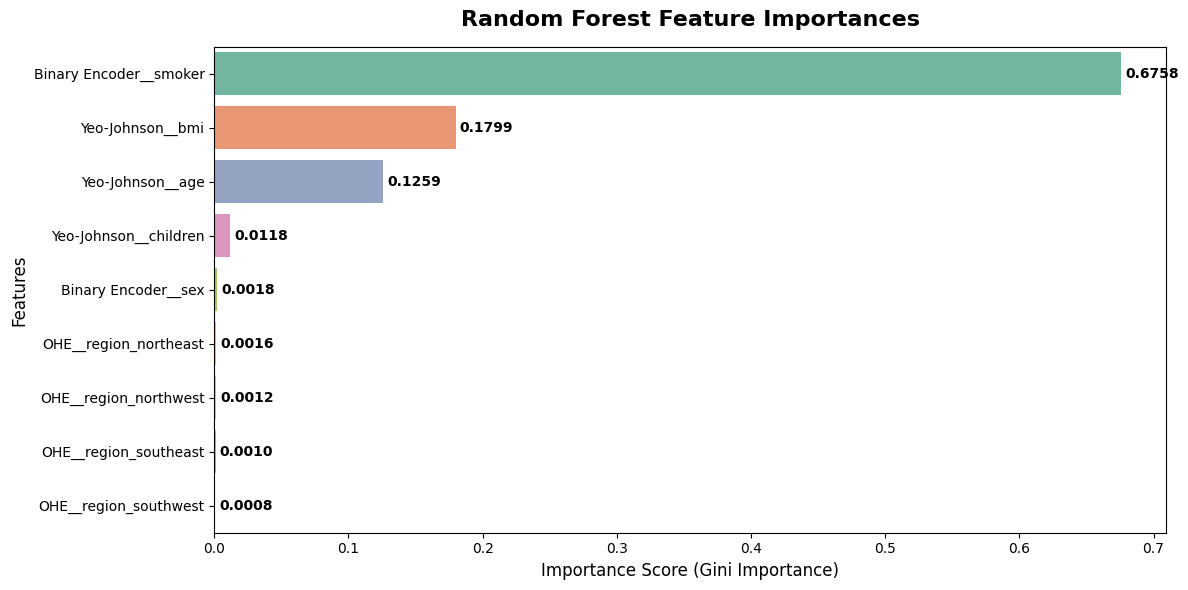

In [35]:
# Local storage path for preserving the generated visual assets
output_dir = "visualizations"
os.makedirs(output_dir, exist_ok=True)

# Isolation of the predictive weight assigned to each independent variable by the model architecture
feature_importances = best_final_model.named_steps["Model"].feature_importances_
feature_names = best_final_model.named_steps["Preprocessing"].get_feature_names_out()

# Structured tabular representation prioritizing the most influential variables at the top
importance_df = pd.DataFrame({
    "Features": feature_names,
    "Importances": feature_importances
}).sort_values(by="Importances", ascending=False).reset_index(drop=True)

# Console interface boundary for the raw numerical metric display
print("\n" + "-" * 70)
print("📊 [DATA] RANDOM FOREST FEATURE IMPORTANCES")
print("-" * 70)
display(importance_df)

# Two-dimensional spatial canvas allocated for the horizontal bar hierarchy
plt.figure(figsize=(12, 6))

# Graphical translation of the variable weights into visual horizontal magnitudes
ax = sns.barplot(
    data=importance_df, 
    x="Importances", 
    y="Features", 
    palette="Set2"
)

# Contextual typography and metadata ensuring the scientific readability of the chart
plt.title("Random Forest Feature Importances", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Importance Score (Gini Importance)", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Precise numerical overlays to complement the visual magnitude of each variable
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=10, fontweight="bold")

plt.tight_layout()

# Permanent physical file allocation for external reporting and documentation
file_path = f"{output_dir}/feature_importances_rf.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

## 10. Evaluating on the Held-Out Test Set

This is the first and only time the model touches the 268-row test set held
out back in Section 4. The printed metrics above report the final model's
R2, MAE, and RMSE on this unseen data. The scatter plot of actual versus
predicted charges, with a diagonal line marking a perfect prediction, is
saved as `actual_vs_predicted_rf.png`.

----------------------------------------------------------------------
✅ [SUCCESS] Model evaluated in 0m 1.37s
----------------------------------------------------------------------
📊 [TEST SET METRICS] : Random Forest Regressor
   - R2 Score         : 0.9014
   - MAE              : 2458.5597
   - RMSE             : 4255.6676



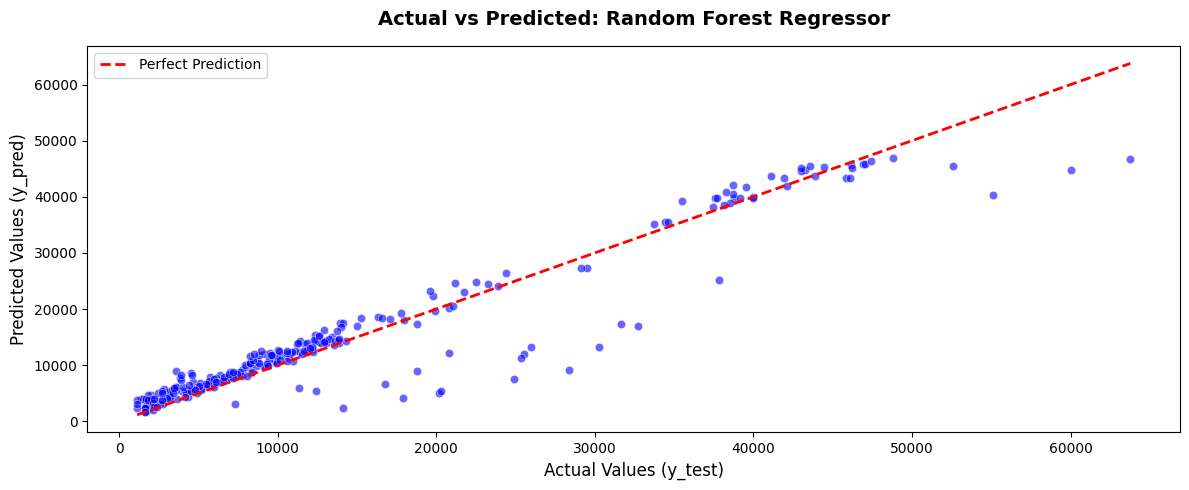

In [36]:
# Generation of target estimations based on the unseen testing distribution
y_pred = best_final_model.predict(X_test)

# Statistical quantification of the model's predictive accuracy against the ground truth data
model_name = "Random Forest Regressor"
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Boundary thresholds ensuring a perfectly symmetrical graphical space for the theoretical baseline
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

# Console interface projection for the finalized evaluation metrics
print("-" * 70)
print(f"✅ [SUCCESS] Model evaluated in {elapsed_time}")
print("-" * 70)
print(f"📊 [TEST SET METRICS] : {model_name}")
print(f"   - R2 Score         : {r2:.4f}")
print(f"   - MAE              : {mae:.4f}")
print(f"   - RMSE             : {rmse:.4f}")
print("="*70 + "\n")

# Spatial matrix mapping the model estimations directly against their corresponding true targets
plt.figure(figsize=(12, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color="blue")

# Theoretical baseline representing a zero-error prediction scenario (y = x)
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red", lw=2, label="Perfect Prediction")

# Contextual metadata and typography enhancing the scientific readability of the distribution map
plt.title(f"Actual vs Predicted: {model_name}", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Actual Values (y_test)", fontsize=12)
plt.ylabel("Predicted Values (y_pred)", fontsize=12)
plt.legend(loc="upper left")
plt.tight_layout()

# Permanent physical file allocation for external reporting and visual documentation
file_path = f"{output_dir}/actual_vs_predicted_rf.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=False)
plt.show()

## 11. Quantile Regression for Prediction Intervals

A single predicted number does not communicate how confident that estimate
actually is. To address that, two extra LightGBM models are trained on the
same training data, one with a quantile objective at `alpha=0.1` (a lower
bound) and one at `alpha=0.9` (an upper bound), so every prediction can be
reported as a Min, Prediction, and Max range instead of one figure.

The next cell demonstrates this on the first 10 rows of the test set. Actual
cost, the predicted lower bound, the point prediction, and the predicted
upper bound are all shown side by side. As the table above shows, the
interval width varies a lot from row to row: non-smoking patients tend to
get a comparatively tight range, while smoking patients tend to get a much
wider one, consistent with `smoker` being the dominant, highest-variance
cost driver identified in Section 9. The R2 reported for this subset is
only illustrative of the interval mechanism on these 10 rows. It is not a
substitute for the 268-sample test metrics from Section 10.

In [37]:
# Terminal UI header for quantile regression modeling
print("\n" + "="*70)
print("📈 [MODELING] LIGHTGBM QUANTILE REGRESSION (PREDICTION INTERVALS)")
print("="*70)

# Pipeline architecture for the 10th percentile lower bound estimation
lgbm_lower = Pipeline(
    steps=[
        ("Preprocessing", transformers),
        ("Model", LGBMRegressor(objective="quantile", alpha=0.1, random_state=random_state, verbose=-1))
    ]
)

# Pipeline architecture for the 90th percentile upper bound estimation
lgbm_upper = Pipeline(
    steps=[
        ("Preprocessing", transformers),
        ("Model", LGBMRegressor(objective="quantile", alpha=0.9, random_state=random_state, verbose=-1))
    ]
)

# Terminal UI output for the execution status
print("[*] Training the lower bound (alpha=0.1) and upper bound (alpha=0.9) models...")

# State configuration of the lower bound model on the training set
lgbm_lower.fit(X_train, y_train)

# State configuration of the upper bound model on the training set
lgbm_upper.fit(X_train, y_train)

# Terminal UI output for training completion
print("-" * 70)
print("✅ [SUCCESS] Quantile regression models successfully trained")
print("="*70 + "\n")


📈 [MODELING] LIGHTGBM QUANTILE REGRESSION (PREDICTION INTERVALS)
[*] Training the lower bound (alpha=0.1) and upper bound (alpha=0.9) models...
----------------------------------------------------------------------
✅ [SUCCESS] Quantile regression models successfully trained



In [38]:
# Subset of 10 instances from the evaluation features for validation
test_data = X_test.iloc[:10]

# Ground truth continuous targets for the corresponding 10 instances
actual_cost = y_test.iloc[:10]

# 1D array of point predictions from the primary optimized model
y_pred_flat = best_final_model.predict(test_data).flatten()

# 1D array of 10th percentile estimations from the lower bound model
min_cost_quantile = lgbm_lower.predict(test_data).flatten()

# 1D array of 90th percentile estimations from the upper bound model
max_cost_quantile = lgbm_upper.predict(test_data).flatten()

# R2 metric representation for this specific 10-sample subset
r2 = r2_score(actual_cost, y_pred_flat)

# Terminal UI header for the prediction interval subset evaluation
print("\n" + "="*70)
print("🔬 [INFERENCE] PREDICTION INTERVALS ON SUBSET (N=10)")
print("="*70)
print(f"📊 [SUBSET METRIC] R2 Score : {r2:.4f}")
print("-" * 70)

# DataFrame structure for the side-by-side financial metric comparison
df_prediction = test_data.copy()

# Formatted string columns for the financial values
df_prediction["Cost"] = [f"${actual:,.2f}" for actual in actual_cost]
df_prediction["Min Cost"] = [f"${cost:,.2f}" for cost in min_cost_quantile]
df_prediction["Prediction"] = [f"${pred:,.2f}" for pred in y_pred_flat]
df_prediction["Max Cost"] = [f"${cost:,.2f}" for cost in max_cost_quantile]

# Console interface presentation for the tabular data
display(df_prediction)
print("="*70 + "\n")


🔬 [INFERENCE] PREDICTION INTERVALS ON SUBSET (N=10)
📊 [SUBSET METRIC] R2 Score : 0.9925
----------------------------------------------------------------------


,age,sex,bmi,children,smoker,region,Cost,Min Cost,Prediction,Max Cost
900,49,male,22.515,0,no,northeast,"$8,688.86","$8,445.34","$10,683.72","$17,045.38"
1064,29,female,25.600,4,no,southwest,"$5,708.87","$5,068.67","$6,167.48","$11,430.35"
1256,51,female,36.385,3,no,northwest,"$11,436.74","$10,824.49","$12,301.26","$22,765.25"
298,31,male,34.390,3,yes,northwest,"$38,746.36","$21,545.19","$39,702.50","$37,403.24"
237,31,male,38.390,2,no,southeast,"$4,463.21","$4,446.08","$5,417.94","$12,562.14"
481,49,male,37.510,2,no,southeast,"$9,304.70","$9,152.69","$10,385.57","$17,632.04"
240,23,female,36.670,2,yes,northeast,"$38,511.63","$9,507.51","$38,872.76","$46,052.15"
277,22,female,24.300,0,no,southwest,"$2,150.47","$2,150.51","$2,378.80","$7,537.96"
415,43,female,35.640,1,no,southeast,"$7,345.73","$7,106.74","$8,534.27","$10,529.45"
707,49,male,28.690,3,no,northwest,"$10,264.44","$9,986.28","$11,890.68","$11,737.31"


## 12. Explaining a Single Prediction with LIME

To make an individual prediction traceable instead of just accurate, a
`LimeTabularExplainer` is built in regression mode on the fully preprocessed
training matrix. The two binary categorical feature indices (`sex`,
`smoker`) are explicitly mapped back to their original text labels
(`Female`/`Male`, `No`/`Yes`) so the explanation reads in plain language
instead of raw encoded numbers. The explainer is then asked to explain the
model's prediction for test instance 0, which corresponds to row 900 in the
original dataframe, a 49-year-old male, non-smoker, BMI of about 22.5, no
children, from the northeast region. The explanation is rendered as an
interactive widget directly in the notebook.

In [39]:
# UI Header for interpretability section
print("\n" + "="*70)
print("🔍 [INTERPRETABILITY] LIME LOCAL EXPLANATION")
print("="*70)

# Preprocessing component and the transformed training dataset
preprocessor = best_final_model.named_steps["Preprocessing"]
X_train_processed = preprocessor.transform(X_train)

# Dense array fallback for LIME compatibility
if scipy.sparse.issparse(X_train_processed):
    X_train_processed = X_train_processed.toarray()
elif hasattr(X_train_processed, "values"):
    X_train_processed = X_train_processed.values

# Array of feature names for LIME output labels
preprocessor.verbose_feature_names_out = False
features = preprocessor.get_feature_names_out()

# List representation of features for index extraction
features_list = list(features)

# Index values for categorical features
sex_idx = features_list.index("sex")
smoker_idx = features_list.index("smoker")

# List array of categorical indices
categorical_features_indices = [sex_idx, smoker_idx]

# Dictionary mapping for categorical feature string labels
categorical_names_map = {
    sex_idx: ["Female", "Male"],
    smoker_idx: ["No", "Yes"]
}

# LIME Tabular Explainer object for regression
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=features,
    categorical_features=categorical_features_indices, 
    categorical_names=categorical_names_map,
    mode="regression",
    random_state=random_state
)

# Patient data point (Instance 0) from the test set
instance_idx = 0
patient_data = test_data.iloc[[instance_idx]]

# Processed patient data point
patient_processed = preprocessor.transform(patient_data)
if scipy.sparse.issparse(patient_processed):
    patient_processed = patient_processed.toarray()
elif hasattr(patient_processed, "values"):
    patient_processed = patient_processed.values

# 1D array format required by the explainer instance
patient_data_1d = patient_processed[0]

# Terminal UI output for execution tracking
print(f"[*] Generating interpretation mapping for Test Set Index: {instance_idx}...")

# LIME explanation object containing top feature contributions
explanation = explainer.explain_instance(
    data_row=patient_data_1d,
    predict_fn=best_final_model.named_steps["Model"].predict,
    num_features=10
)

# Interactive visual explanation output
print("-" * 70)
explanation.show_in_notebook(show_table=True, show_all=False)


🔍 [INTERPRETABILITY] LIME LOCAL EXPLANATION
[*] Generating interpretation mapping for Test Set Index: 0...
----------------------------------------------------------------------


### 12.1 Raw vs. Processed Patient Record

For reference, this cell prints the same patient's record twice: first in
its original raw form, and then after passing through the fitted
preprocessing pipeline (Yeo-Johnson-transformed numeric values, and the
categorical columns mapped back to readable `male`/`female` and `no`/`yes`
labels for display purposes).

In [40]:
# Terminal UI header for the data comparison
print("\n" + "="*70)
print("🔬 [DATA] RAW VS PROCESSED PATIENT INSTANCE")
print("="*70)

# Raw feature matrix for the selected patient instance
print("📌 [RAW DATA]:")
display(patient_data)
print("-" * 70)

# Transformed numerical array of the patient features
processed_patient_data = preprocessor.transform(patient_data)
processed_patient_data["smoker"] = processed_patient_data["smoker"].map({0: "no", 1: "yes"})
processed_patient_data["sex"] = processed_patient_data["sex"].map({0: "female", 1: "male"})

# Console interface presentation for the transformed matrix
print("📌 [PROCESSED DATA]:")
display(processed_patient_data)
print("="*70 + "\n")


🔬 [DATA] RAW VS PROCESSED PATIENT INSTANCE
📌 [RAW DATA]:


,age,sex,bmi,children,smoker,region
900,49,male,22.515,0,no,northeast


----------------------------------------------------------------------
📌 [PROCESSED DATA]:


,age,bmi,children,sex,smoker,region_northeast,region_northwest,region_southeast,region_southwest
900,0.729013,-1.386815,-1.07602,male,no,1.0,0.0,0.0,0.0


### 12.2 Reading the Contribution Weights as Plain Text

The same LIME explanation is also printed as a plain list of
feature-condition and weight pairs, which is easier to log or reuse outside
a notebook environment than the interactive HTML widget above. For this
patient, `smoker=No` is overwhelmingly the largest contributor, far
outweighing every other factor, as shown in the output above. The next
largest effects come from BMI and age, while `children` and every region
and sex indicator contribute only marginally. This lines up closely with
the global feature importances from Section 9, where `smoker` also
dominated by a wide margin.

In [41]:
# List of tuples containing feature conditions and their corresponding LIME weights
feature_weights = explanation.as_list()

# Terminal UI header for the numerical weight breakdown
print("\n" + "-" * 70)
print("⚖️ [DATA] LOCAL FEATURE CONTRIBUTIONS")
print("-" * 70)

# Formatted string output for individual feature impacts
for feature, weight in feature_weights:
    # Cleaned feature string without pipeline prefix
    clean_feature = feature.replace('Model__', '').replace('Model_', '')
    print(f"   - {clean_feature:<45} : {weight:+.4f}")

print("=" * 70 + "\n")


----------------------------------------------------------------------
⚖️ [DATA] LOCAL FEATURE CONTRIBUTIONS
----------------------------------------------------------------------
   - smoker=No                                     : -21910.0730
   - bmi <= -0.69                                  : -2666.7074
   - 0.06 < age <= 0.86                            : +1095.3889
   - children <= -1.08                             : -532.0261
   - region_southwest <= 0.00                      : +453.2250
   - region_northwest <= 0.00                      : -301.7644
   - region_northeast > 0.00                       : +239.5576
   - region_southeast <= 0.00                      : -146.0746
   - sex=Male                                      : +112.0053



### 12.3 Exporting the LIME Chart as an Image

The same explanation is regenerated as a static Matplotlib bar chart rather
than the interactive widget, with numeric labels added to each bar, and
saved as `lime_explanation_rf.png` so it can be reused outside the notebook,
for example in a README or a written report.


🎨 [VISUALIZATION] EXPORTING LIME EXPLANATION PLOT


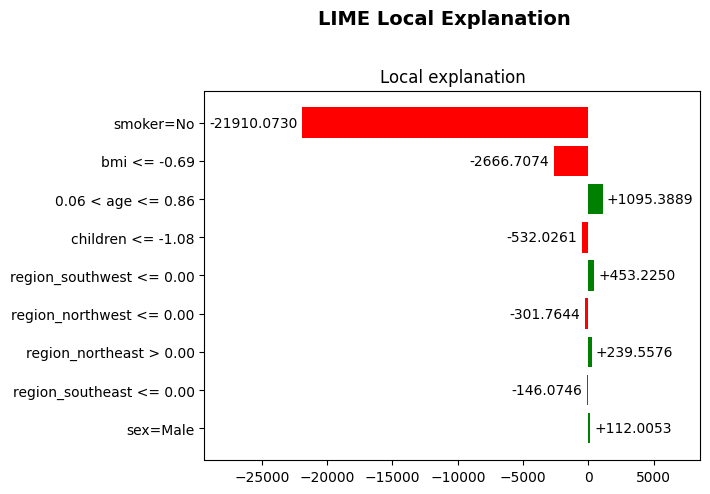

✅ [SUCCESS] LIME plot saved to : visualizations/lime_explanation_rf.png



In [42]:
# Console interface boundary for the visual explanation export
print("\n" + "="*70)
print("🎨 [VISUALIZATION] EXPORTING LIME EXPLANATION PLOT")
print("="*70)

# Local storage directory for LIME visual outputs
output_dir = "visualizations"
os.makedirs(output_dir, exist_ok=True)

# Matplotlib figure object from the LIME explanation
fig = explanation.as_pyplot_figure()
fig.suptitle("LIME Local Explanation", fontsize=14, fontweight="bold", y=1.05)

# Primary axes object of the figure
ax = fig.axes[0]

# Numerical text annotations for the bar containers
for container in ax.containers:
    ax.bar_label(container, fmt="%+.4f", padding=3)

# X-axis boundary limits and horizontal margin metrics
xmin, xmax = ax.get_xlim()
pad = (xmax - xmin) * 0.25
ax.set_xlim(xmin - pad, xmax + pad)

# Destination file path for the PNG image format
file_path = f"{output_dir}/lime_explanation_rf.png"
fig.savefig(file_path, dpi=300, bbox_inches="tight", transparent=False)

# Render the generated plot directly to the interactive display
plt.show()

# Figure memory clearance
plt.close(fig)

# Terminal UI output for the export status
print(f"✅ [SUCCESS] LIME plot saved to : {file_path}")
print("="*70 + "\n")

## 13. Saving Final Artifacts

The last step serializes everything needed to reuse this model without
re-running the notebook: the preprocessed training matrix
(`X_train_processed.npy`, also usable as LIME's background data elsewhere),
the full tuned pipeline (`best_final_model.joblib`), and both quantile
models (`lgbm_lower_bound.joblib`, `lgbm_upper_bound.joblib`), all written
into an `artifacts/` folder.

In [43]:
# Directory path for serialized model artifacts and processed data
artifact_dir = "artifacts"
os.makedirs(artifact_dir, exist_ok=True)

# Terminal UI header for the serialization process
print("\n" + "="*70)
print("💾 [SERIALIZATION] EXPORTING MODELS AND DATA ARTIFACTS")
print("="*70)

# File path for the serialized preprocessed training feature matrix
x_train_path = f"{artifact_dir}/X_train_processed.npy"

# NPY format export of the dense numpy array
np.save(x_train_path, X_train_processed)

# File paths for the optimized predictive models
final_model_path = f"{artifact_dir}/best_final_model.joblib"
lower_bound_model_path = f"{artifact_dir}/lgbm_lower_bound.joblib"
upper_bound_model_path = f"{artifact_dir}/lgbm_upper_bound.joblib"

# Serialized binary files of the trained estimator objects
joblib.dump(best_final_model, final_model_path)
joblib.dump(lgbm_lower, lower_bound_model_path)
joblib.dump(lgbm_upper, upper_bound_model_path)

# Terminal UI output for artifact locations
print(f"✅ [SUCCESS] X_train Matrix : {x_train_path}")
print(f"✅ [SUCCESS] Main Model     : {final_model_path}")
print(f"✅ [SUCCESS] Lower Bound    : {lower_bound_model_path}")
print(f"✅ [SUCCESS] Upper Bound    : {upper_bound_model_path}")
print("="*70 + "\n")


💾 [SERIALIZATION] EXPORTING MODELS AND DATA ARTIFACTS
✅ [SUCCESS] X_train Matrix : artifacts/X_train_processed.npy
✅ [SUCCESS] Main Model     : artifacts/best_final_model.joblib
✅ [SUCCESS] Lower Bound    : artifacts/lgbm_lower_bound.joblib
✅ [SUCCESS] Upper Bound    : artifacts/lgbm_upper_bound.joblib



## 14. Conclusion

This notebook set out to answer three separate questions about medical
insurance costs, not just to fit a single model. Which algorithm actually
fits the non-linear cost pattern in this data, how tuning strategies compare
against each other, and how a single point estimate can be turned into
something more useful than just a number. A 9-model cross-validation
benchmark showed that only Random Forest and LightGBM meaningfully captured
the non-linear structure in the data, both clearing a wide margin over every
linear-family model. Because those two models finished so close together,
both were carried through three separate tuning strategies rather than
committing early, and Optuna-tuned Random Forest came out on top, only
narrowly ahead of Optuna-tuned LightGBM. That final model reached a strong
R2 on the held-out test set (see Section 10 for the exact figures). On top
of that point estimate, LightGBM quantile regressors added a Min-to-Max
interval around each prediction, and LIME made individual predictions
traceable back to specific features, confirming numerically what the EDA
already hinted at: `smoker` status alone drives the large majority of this
model's decisions.

## 15. Limitations

* **Hardcoded dataset path.** The CSV path is a fixed Kaggle input path
  written directly into an early cell. Running this notebook outside Kaggle
  means manually finding and editing that path first, which makes the
  notebook harder to reuse as-is.
* **Small quantile interval sanity check.** The Min, Prediction, and Max
  demo in Section 11 is only run on 10 rows as an illustrative example. It
  has not been evaluated as a properly calibrated interval across the full
  268-row test set, so there is no real evidence yet for how often the true
  cost actually falls inside the predicted interval at scale.
* **Small dataset.** After removing 1 duplicate, only 1,337 records remain,
  1,069 of which were used for training. Unusual combinations, such as an
  older smoker with a very high BMI in an underrepresented region, are
  barely present in the data, so predictions for those less common profiles
  should be trusted less than predictions for typical ones.
* **Heavy reliance on a single feature.** `smoker` alone accounts for the
  large majority of the Random Forest's feature importance (see Section 9).
  That concentration means the model would likely be far less reliable on a
  population where smoking status is missing, misreported, or simply a
  weaker signal than it is in this dataset.
* **Region contributes almost nothing.** Every one-hot `region` column shows
  near-zero importance here. In reality, healthcare pricing does vary
  geographically, so this most likely reflects this dataset's limited
  sample size per region rather than genuine evidence that location does not
  matter for medical costs in general.
* **LIME explanation shown for a single instance.** Only one test patient
  (index 0) is explained as a demonstration in Section 12. It has not been
  run across the rest of the test set, so there is no current evidence for
  how stable or consistent LIME's explanations are from one similar patient
  to the next.
* **Notebook only, no application layer.** This is a self-contained analysis
  notebook, not a deployed tool. There is no Streamlit, Gradio, or API layer
  sitting on top of the serialized artifacts from Section 13, so using this
  model outside the notebook currently requires writing that integration
  from scratch.

## 16. Suggestions for Future Work

* **Parameterize the dataset path.** Replace the hardcoded Kaggle path with
  a CLI argument, environment variable, or config value, so the same
  notebook or an equivalent script can run unmodified on Kaggle, on a
  laptop, or in a CI job.
* **Evaluate quantile coverage on the full test set.** Extend the 10-row
  demo in Section 11 into a proper coverage check across all 268 held-out
  rows, measuring what fraction of actual charges genuinely fall between the
  predicted lower and upper bounds, which is the real test of whether the
  interval is trustworthy rather than just illustrative.
* **Compare LIME against SHAP.** Running SHAP on the same instances explained
  with LIME in Section 12 would show whether the two explanation methods
  agree on which features matter most, and SHAP's stronger theoretical
  consistency guarantees could help validate LIME's results here.
* **Explore stacking or ensembling.** `StackingRegressor` is already
  imported in Section 1 but unused. Given how close Random Forest and
  LightGBM ended up performing after tuning, combining their predictions
  could plausibly outperform either model alone if their errors turn out to
  be only weakly correlated.
* **Source more or more diverse data.** A larger or more geographically
  varied insurance dataset would help confirm whether patterns like the
  near-zero importance of `region` genuinely hold, or are simply an artifact
  of this dataset's limited size.
* **Wrap the artifacts in a lightweight app.** Loading
  `best_final_model.joblib` and the two quantile models into a small
  Streamlit or Gradio interface would let a non-technical user get a point
  estimate, an interval, and a LIME explanation through a form, instead of
  needing to open and run this notebook directly.